# Systematic Trading Strategies with Machine Learning  
## Coursework Project – Meta-Labeling for Trading Signal Filtering

---

# 1. Project Overview

The objective of this project is to build a **metamodel** on top of a provided primary trading signal across futures contracts from multiple asset classes.

The primary model generates daily trading signals in \(\{-1,0,+1\}\):
- \(+1\): long signal
- \(-1\): short signal
- \(0\): no position

Our goal is **not** to predict returns directly.  
Instead, we aim to estimate the probability that a given primary signal is worth taking under a triple-barrier labeling framework.

More formally, we seek to model:

\[
P(\text{Trade is profitable} \mid \text{Features})
\]

using machine learning techniques.

---

# 2. Project Pipeline

The project is structured into the following stages:

## Phase 1 — Data Preparation and Exploration
- Load and clean OHLCV data
- Load and align primary signals
- Verify data integrity and temporal consistency
- Explore the characteristics of each asset class

## Phase 2 — Feature Engineering
Construction of predictive features from market data, including:
- Technical indicators
- Volatility and momentum features
- Cross-sectional features
- Latent regime features (HMM/GMM)
- Additional engineered features

## Phase 3 — Triple-Barrier Labeling
Implementation of the triple-barrier method to define supervised learning targets:
- Profit-taking barrier
- Stop-loss barrier
- Maximum holding period

We will justify all parameter choices economically and statistically.

## Phase 4 — Model Development
We will compare several model families:
- Linear models
- Tree-based ensemble methods
- Neural networks

Hyperparameter tuning and robust validation procedures will be applied.

## Phase 5 — Feature Importance Analysis
We will study:
- Individual feature importance
- Cluster-level feature importance
- SHAP/permutation-based interpretability

## Phase 6 — Out-of-Sample Evaluation
Evaluation on a clean out-of-sample period using:
- Precision
- Recall
- F1-score
- ROC-AUC
- Confusion matrices
- Comparison against the raw primary signal

## Optional Phase 7 — Strategy Construction
(Optional competition track)

Construction of a position-sizing strategy using metamodel probabilities.

---

# 3. Methodological Principles

Throughout the project, particular attention will be paid to:
- Avoiding look-ahead bias
- Preventing data leakage
- Using time-aware validation procedures
- Ensuring reproducibility
- Maintaining economic interpretability of results

The emphasis of this coursework is placed on:
- methodological rigor,
- feature engineering quality,
- validation protocol,
- and critical analysis of results.

---

# 4. Asset Universe

The project covers futures contracts from three asset classes:

## Equity Index Futures
- ES1S — S&P 500
- NQ1S — Nasdaq 100
- FESX1S — Euro Stoxx 50

## Energy
- CL1S — WTI Crude Oil
- HO1S — Heating Oil
- RB1S — RBOB Gasoline
- NG1S — Natural Gas

## Metals
- GC1S — Gold
- SI1S — Silver
- HG1S — Copper
- PL1S — Platinum

---

# 5. Initial Setup

We begin by importing the required libraries and loading the datasets.

# Phase 1 — Data Preparation and Initial Exploration

In this first phase, we prepare the raw datasets for the meta-labeling pipeline.

We focus initially on the **Energy** asset class:

| Ticker | Commodity |
|---|---|
| CL1S | WTI Crude Oil |
| HO1S | Heating Oil |
| RB1S | RBOB Gasoline |
| NG1S | Natural Gas |

The objectives of this phase are:

1. Load the OHLCV dataset and the primary signals dataset.
2. Standardize dates, instrument names, and column formats.
3. Filter the universe to Energy instruments only.
4. Align market data and primary signals on a common trading calendar.
5. Perform basic data integrity checks:
   - missing values,
   - duplicated rows,
   - date coverage,
   - signal distribution,
   - price and volume sanity checks.
6. Prepare a clean base dataframe that will later be used for feature engineering and triple-barrier labeling.

At this stage, we do **not** create labels yet.  
The purpose is to build a clean, reliable data foundation before moving to feature engineering.

In [86]:
# ============================================================
# Phase 1 — Setup and Data Loading
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Display options
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)

# ------------------------------------------------------------
# Project configuration
# ------------------------------------------------------------

DATA_DIR = "."  # Change this path if your CSV files are in another folder

OHLCV_FILE = os.path.join(DATA_DIR, "ohlcv_data.csv")
SIGNALS_FILE = os.path.join(DATA_DIR, "primary_signals.csv")

ENERGY_INSTRUMENTS = ["cl1s", "ho1s", "rb1s", "ng1s"]

INSTRUMENT_NAMES = {
    "cl1s": "WTI Crude Oil",
    "ho1s": "Heating Oil",
    "rb1s": "RBOB Gasoline",
    "ng1s": "Natural Gas",
}

print("Energy universe:")
for ticker, name in INSTRUMENT_NAMES.items():
    print(f"- {ticker.upper()}: {name}")

Energy universe:
- CL1S: WTI Crude Oil
- HO1S: Heating Oil
- RB1S: RBOB Gasoline
- NG1S: Natural Gas


In [87]:
# ============================================================
# Load Raw Data
# ============================================================

ohlcv_raw = pd.read_csv(OHLCV_FILE)
signals_raw = pd.read_csv(SIGNALS_FILE)

print("OHLCV shape:", ohlcv_raw.shape)
print("Signals shape:", signals_raw.shape)

display(ohlcv_raw.head())
display(signals_raw.head())

OHLCV shape: (83547, 8)
Signals shape: (645, 12)


,date,instrument,open,high,low,close,volume,open_interest
0,1990-01-02,cl1s,21.8000,22.920,21.7900,22.8900,22868.0,66308.0
1,1990-01-02,gc1s,401.0000,404.600,400.2000,402.1000,20747.0,68855.0
2,1990-01-02,hg1s,1.0470,1.064,1.0430,1.0620,3325.0,19735.0
3,1990-01-02,ho1s,0.7475,0.776,0.7415,0.7739,20280.0,33732.0
4,1990-01-02,pl1s,484.0000,485.000,479.5000,482.2000,4561.0,13256.0


,date,es1s,nq1s,fesx1s,cl1s,ho1s,rb1s,ng1s,gc1s,si1s,hg1s,pl1s
0,2020-01-03,1,1,-1,0,0,1,0,0,1,1,-1
1,2020-01-06,1,-1,1,0,0,1,0,0,1,1,1
2,2020-01-07,1,-1,1,-1,0,-1,0,0,1,1,1
3,2020-01-08,1,1,1,0,0,1,0,0,1,1,1
4,2020-01-09,1,-1,-1,0,0,1,0,0,1,1,1


## 1.1 Initial Data Standardization

We now standardize the two datasets:

- convert dates to `datetime`,
- convert instrument names to lowercase,
- sort observations chronologically,
- filter the OHLCV data and primary signals to the Energy instruments only.

This ensures that both datasets use the same naming convention and can later be merged safely.

In [88]:
# ============================================================
# Standardize Dates and Instrument Names
# ============================================================

ohlcv = ohlcv_raw.copy()
signals = signals_raw.copy()

# Convert date columns
ohlcv["date"] = pd.to_datetime(ohlcv["date"])
signals["date"] = pd.to_datetime(signals["date"])

# Standardize instrument names
ohlcv["instrument"] = ohlcv["instrument"].str.lower()

# Keep only Energy instruments
ohlcv_energy = ohlcv[ohlcv["instrument"].isin(ENERGY_INSTRUMENTS)].copy()

# Keep date + Energy signal columns
signals_energy = signals[["date"] + ENERGY_INSTRUMENTS].copy()

# Sort
ohlcv_energy = ohlcv_energy.sort_values(["instrument", "date"]).reset_index(drop=True)
signals_energy = signals_energy.sort_values("date").reset_index(drop=True)

print("Energy OHLCV shape:", ohlcv_energy.shape)
print("Energy signals shape:", signals_energy.shape)

display(ohlcv_energy.head())
display(signals_energy.head())

Energy OHLCV shape: (32614, 8)
Energy signals shape: (645, 5)


,date,instrument,open,high,low,close,volume,open_interest
0,1990-01-02,cl1s,21.80,22.92,21.79,22.89,22868.0,66308.0
1,1990-01-03,cl1s,23.20,23.80,23.00,23.68,45177.0,61428.0
2,1990-01-04,cl1s,23.88,23.92,22.83,23.41,50061.0,60995.0
3,1990-01-05,cl1s,23.42,23.70,23.03,23.08,53070.0,57258.0
4,1990-01-08,cl1s,22.60,22.60,21.55,21.62,39720.0,54644.0


,date,cl1s,ho1s,rb1s,ng1s
0,2020-01-03,0,0,1,0
1,2020-01-06,0,0,1,0
2,2020-01-07,-1,0,-1,0
3,2020-01-08,0,0,1,0
4,2020-01-09,0,0,1,0


## 1.2 Data Integrity Checks

Before creating features or labels, we first verify the quality of the raw Energy datasets.

We check:
- date coverage by instrument,
- duplicated observations,
- missing values,
- OHLCV consistency,
- and primary signal distributions.

These checks are important because any data issue at this stage could later create misleading labels, feature leakage, or incorrect model evaluation.

In [89]:
# ============================================================
# Basic Data Integrity Checks
# ============================================================

print("OHLCV date range by instrument:")
display(
    ohlcv_energy
    .groupby("instrument")["date"]
    .agg(["min", "max", "count"])
)

print("\nSignals date range:")
display(
    signals_energy["date"].agg(["min", "max", "count"])
)

print("\nDuplicate OHLCV rows by (date, instrument):")
n_dup_ohlcv = ohlcv_energy.duplicated(subset=["date", "instrument"]).sum()
print(n_dup_ohlcv)

print("\nDuplicate signal dates:")
n_dup_signals = signals_energy.duplicated(subset=["date"]).sum()
print(n_dup_signals)

print("\nMissing values in OHLCV:")
display(ohlcv_energy.isna().sum())

print("\nMissing values in signals:")
display(signals_energy.isna().sum())

OHLCV date range by instrument:


,min,max,count
instrument,,,
cl1s,1990-01-02,2022-06-30,8171
ho1s,1990-01-02,2022-06-30,8169
ng1s,1990-04-04,2022-06-30,8104
rb1s,1990-01-02,2022-06-30,8170



Signals date range:


min      2020-01-03 00:00:00
max      2022-06-30 00:00:00
count                    645
Name: date, dtype: object


Duplicate OHLCV rows by (date, instrument):
0

Duplicate signal dates:
0

Missing values in OHLCV:


date             0
instrument       0
open             0
high             0
low              0
close            0
volume           0
open_interest    0
dtype: int64


Missing values in signals:


date    0
cl1s    0
ho1s    0
rb1s    0
ng1s    0
dtype: int64

## 1.3 Signal Distribution Analysis

Before building labels or training models, we inspect the distribution of the primary signals.

This is important because:
- the dataset may be imbalanced,
- some instruments may trade much more frequently than others,
- and the proportion of long/short/flat signals may affect both labeling and model performance.

We therefore compute the distribution of:
- long signals (+1),
- short signals (-1),
- and inactive periods (0),
for each Energy instrument.

In [90]:
# ============================================================
# Signal Distribution
# ============================================================

signal_distribution = {}

for inst in ENERGY_INSTRUMENTS:
    
    counts = (
        signals_energy[inst]
        .value_counts()
        .sort_index()
    )
    
    signal_distribution[inst] = counts

    print(f"\n{inst.upper()} signal distribution:")
    print(counts)

    print("\nPercentages:")
    print((counts / counts.sum() * 100).round(2))


CL1S signal distribution:
cl1s
-1     36
 0    223
 1    386
Name: count, dtype: int64

Percentages:
cl1s
-1     5.58
 0    34.57
 1    59.84
Name: count, dtype: float64

HO1S signal distribution:
ho1s
-1     10
 0    582
 1     53
Name: count, dtype: int64

Percentages:
ho1s
-1     1.55
 0    90.23
 1     8.22
Name: count, dtype: float64

RB1S signal distribution:
rb1s
-1    261
 0     17
 1    367
Name: count, dtype: int64

Percentages:
rb1s
-1    40.47
 0     2.64
 1    56.90
Name: count, dtype: float64

NG1S signal distribution:
ng1s
-1    124
 0    521
Name: count, dtype: int64

Percentages:
ng1s
-1    19.22
 0    80.78
Name: count, dtype: float64


## 1.4 OHLC Consistency Checks

We now perform several sanity checks on the OHLC data.

For each observation, financial market conventions imply:


$\text{low} \leq \text{open, close} \leq \text{high}$


Violations of these inequalities may indicate:
- corrupted observations,
- bad data adjustments,
- or preprocessing issues.

We also verify that prices and trading activity remain strictly positive.

In [91]:
# ============================================================
# OHLC Consistency Checks
# ============================================================

# High should be >= low
invalid_high_low = (ohlcv_energy["high"] < ohlcv_energy["low"]).sum()

# Open should lie inside [low, high]
invalid_open = (
    (ohlcv_energy["open"] < ohlcv_energy["low"]) |
    (ohlcv_energy["open"] > ohlcv_energy["high"])
).sum()

# Close should lie inside [low, high]
invalid_close = (
    (ohlcv_energy["close"] < ohlcv_energy["low"]) |
    (ohlcv_energy["close"] > ohlcv_energy["high"])
).sum()

# Negative or zero prices
non_positive_prices = (
    (ohlcv_energy[["open", "high", "low", "close"]] <= 0)
    .sum()
    .sum()
)

print("Invalid high/low rows:", invalid_high_low)
print("Invalid open rows:", invalid_open)
print("Invalid close rows:", invalid_close)
print("Non-positive prices:", non_positive_prices)

Invalid high/low rows: 0
Invalid open rows: 0
Invalid close rows: 0
Non-positive prices: 0


## 1.5 Price Series Visualization

We now visualize the historical closing prices of the Energy futures contracts.

The objective is not yet predictive modeling, but rather:
- understanding the long-term behavior of each market,
- identifying volatility regimes,
- detecting structural breaks and crises,
- and building intuition about the data before feature engineering.

Since commodity futures can exhibit very different scales and volatility levels, each instrument is plotted separately.

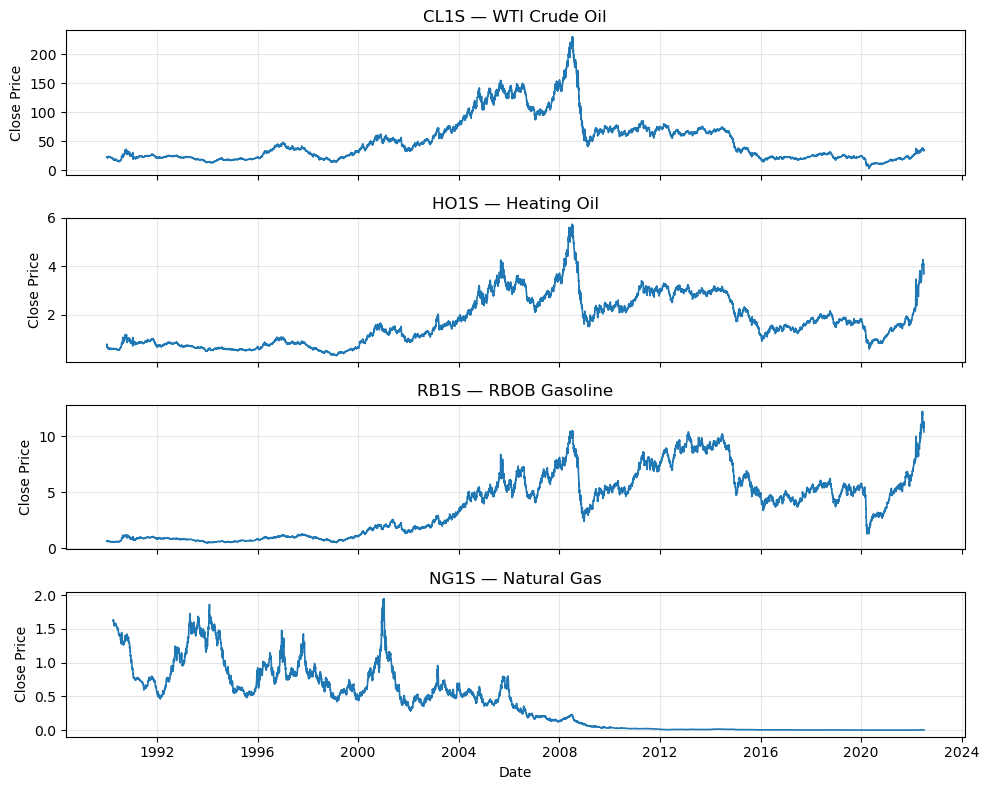

In [92]:
# ============================================================
# Historical Price Visualization
# ============================================================

fig, axes = plt.subplots(
    nrows=4,
    ncols=1,
    figsize=(10, 8),
    sharex=True
)

for ax, inst in zip(axes, ENERGY_INSTRUMENTS):

    df_inst = ohlcv_energy[
        ohlcv_energy["instrument"] == inst
    ]

    ax.plot(
        df_inst["date"],
        df_inst["close"],
        linewidth=1.2
    )

    ax.set_title(
        f"{inst.upper()} — {INSTRUMENT_NAMES[inst]}",
        fontsize=12
    )

    ax.set_ylabel("Close Price")

    ax.grid(True, alpha=0.3)

plt.xlabel("Date")
plt.tight_layout()
plt.show()

## 1.6 Return Series Construction

Financial machine learning models are generally built on returns rather than raw price levels.

We therefore compute daily log returns for each instrument:

$$
r_t = \log\left(\frac{P_t}{P_{t-1}}\right)
$$

Log returns are preferred because:
- they are additive through time,
- more statistically stable than prices,
- and largely invariant to the absolute price scale.

This is particularly important for futures contracts, where continuous-contract adjustments may distort long-term price levels.

In [93]:
# ============================================================
# Daily Log Returns
# ============================================================

ohlcv_energy["log_return"] = (
    ohlcv_energy
    .groupby("instrument")["close"]
    .transform(lambda x: np.log(x / x.shift(1)))
)

display(
    ohlcv_energy[
        ["date", "instrument", "close", "log_return"]
    ].head(10)
)

,date,instrument,close,log_return
0,1990-01-02,cl1s,22.89,NaN
1,1990-01-03,cl1s,23.68,0.033931
2,1990-01-04,cl1s,23.41,-0.011468
3,1990-01-05,cl1s,23.08,-0.014197
4,1990-01-08,cl1s,21.62,-0.065348
5,1990-01-09,cl1s,22.07,0.020600
6,1990-01-10,cl1s,22.90,0.036918
7,1990-01-11,cl1s,23.14,0.010426
8,1990-01-12,cl1s,23.13,-0.000432
9,1990-01-15,cl1s,22.36,-0.033857


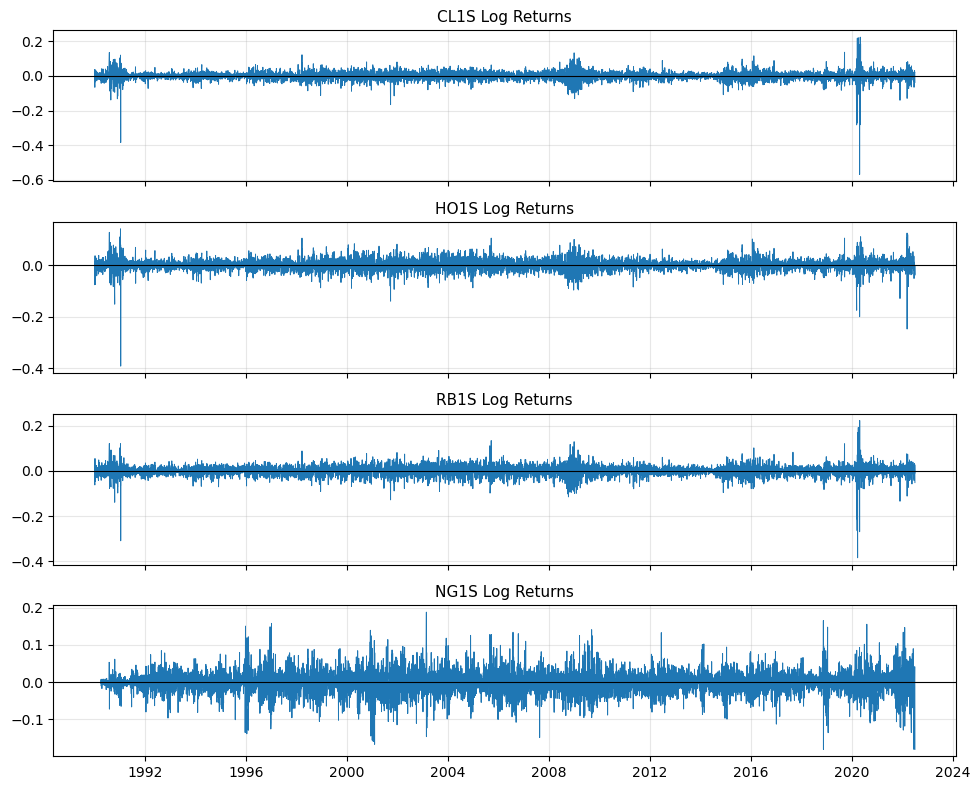

In [94]:
# ============================================================
# Log Return Visualization
# ============================================================

fig, axes = plt.subplots(
    nrows=4,
    ncols=1,
    figsize=(10, 8),
    sharex=True
)

for ax, inst in zip(axes, ENERGY_INSTRUMENTS):

    df_inst = ohlcv_energy[
        ohlcv_energy["instrument"] == inst
    ]

    ax.plot(
        df_inst["date"],
        df_inst["log_return"],
        linewidth=0.7
    )

    ax.set_title(
        f"{inst.upper()} Log Returns",
        fontsize=11
    )

    ax.axhline(0, color="black", linewidth=0.8)

    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 1.7 Reshaping Primary Signals

The primary signal dataset is currently stored in a wide format:

| date | cl1s | ho1s | rb1s | ng1s |
|---|---|---|---|---|

However, the OHLCV dataset is stored in long format:

| date | instrument | open | high | low | close | ... |

To simplify merging and downstream processing, we reshape the signal dataset into long format using `pandas.melt()`.

The resulting structure becomes:

| date | instrument | signal |
|---|---|---|

This representation is much more convenient for:
- feature engineering,
- labeling,
- merging datasets,
- and machine learning pipelines.

In [95]:
# ============================================================
# Reshape Signals to Long Format
# ============================================================

signals_long = signals_energy.melt(
    id_vars="date",
    value_vars=ENERGY_INSTRUMENTS,
    var_name="instrument",
    value_name="primary_signal"
)

signals_long = (
    signals_long
    .sort_values(["instrument", "date"])
    .reset_index(drop=True)
)

print("Signals long shape:", signals_long.shape)

display(signals_long.head(10))

Signals long shape: (2580, 3)


,date,instrument,primary_signal
0,2020-01-03,cl1s,0
1,2020-01-06,cl1s,0
2,2020-01-07,cl1s,-1
3,2020-01-08,cl1s,0
4,2020-01-09,cl1s,0
5,2020-01-10,cl1s,0
6,2020-01-13,cl1s,0
7,2020-01-14,cl1s,0
8,2020-01-15,cl1s,0
9,2020-01-16,cl1s,0


# Phase 2 — Feature Engineering

In this phase, we construct predictive features from the Energy OHLCV dataset.

The objective is to describe the market environment in which each primary signal occurs.  
These features will later be used by the metamodel to estimate whether a given primary trading signal is worth taking.

We construct features separately for each instrument, using only past and current information available at each date.  
This is essential to avoid look-ahead bias.

The feature engineering process is organized into several blocks:

1. **Core return and momentum features**
   - daily returns,
   - rolling cumulative returns,
   - short-term and medium-term momentum.

2. **Volatility features**
   - rolling realized volatility,
   - volatility ratios,
   - volatility regime indicators.

3. **Volume and open-interest features**
   - volume changes,
   - volume z-scores,
   - open-interest changes.

4. **Technical indicators**
   - RSI,
   - MACD,
   - Bollinger-style z-scores.

5. **Time-series dependence features**
   - rolling autocorrelation,
   - volatility clustering proxies,
   - trend persistence measures.

6. **Cross-sectional features**
   - relative momentum,
   - relative volatility,
   - ranks within the Energy asset class.

7. **Latent regime features**
   - GMM/HMM-based regime probabilities,
   - market turbulence indicators.

At this stage, we start with a robust set of core statistical features before adding more advanced indicators.

## 2.1 Core Return and Momentum Features

We begin with a set of core return-based and momentum features.

Momentum features aim to capture whether an instrument has recently experienced persistent positive or negative price movements.  
Such features are widely used in systematic trading strategies, where trend-following and persistence effects often play an important role.

For each instrument, we compute rolling momentum over several horizons:

$$
\text{mom}_{k,t}
=
\log\left(\frac{P_t}{P_{t-k}}\right)
$$

where:
- \(P_t\) is the closing price at time \(t\),
- and \(k\) represents the lookback horizon.

We use multiple horizons in order to capture:
- short-term momentum,
- medium-term trends,
- and longer-term price persistence.

In addition, we compute rolling average returns:

$$
\bar r_t^{(k)}
=
\frac{1}{k}
\sum_{i=0}^{k-1} r_{t-i}
$$

which provide smoother estimates of recent market direction and local return persistence.

All features are computed independently for each instrument using:

```python
groupby("instrument")

In [96]:
# ============================================================
# Phase 2 — Feature Engineering Setup
# ============================================================

features_df = ohlcv_energy.copy()

# Make sure data is sorted before computing rolling/grouped features
features_df = (
    features_df
    .sort_values(["instrument", "date"])
    .reset_index(drop=True)
)

print("Feature engineering base shape:", features_df.shape)
display(features_df.head())

Feature engineering base shape: (32614, 9)


,date,instrument,open,high,low,close,volume,open_interest,log_return
0,1990-01-02,cl1s,21.80,22.92,21.79,22.89,22868.0,66308.0,NaN
1,1990-01-03,cl1s,23.20,23.80,23.00,23.68,45177.0,61428.0,0.033931
2,1990-01-04,cl1s,23.88,23.92,22.83,23.41,50061.0,60995.0,-0.011468
3,1990-01-05,cl1s,23.42,23.70,23.03,23.08,53070.0,57258.0,-0.014197
4,1990-01-08,cl1s,22.60,22.60,21.55,21.62,39720.0,54644.0,-0.065348


In [97]:
# ============================================================
# Core Return and Momentum Features
# ============================================================

MOMENTUM_WINDOWS = [5, 10, 20, 60]

for window in MOMENTUM_WINDOWS:
    
    features_df[f"momentum_{window}d"] = (
        features_df
        .groupby("instrument")["close"]
        .transform(lambda x: np.log(x / x.shift(window)))
    )

# Rolling mean return features
RETURN_MEAN_WINDOWS = [5, 20, 60]

for window in RETURN_MEAN_WINDOWS:
    
    features_df[f"mean_return_{window}d"] = (
        features_df
        .groupby("instrument")["log_return"]
        .transform(lambda x: x.rolling(window=window).mean())
    )

display(
    features_df[
        ["date", "instrument", "close", "log_return",
         "momentum_5d", "momentum_20d", "momentum_60d",
         "mean_return_5d", "mean_return_20d"]
    ].head(25)
)

,date,instrument,close,log_return,momentum_5d,momentum_20d,momentum_60d,mean_return_5d,mean_return_20d
0,1990-01-02,cl1s,22.890000,NaN,NaN,NaN,NaN,NaN,NaN
1,1990-01-03,cl1s,23.680000,0.033931,NaN,NaN,NaN,NaN,NaN
2,1990-01-04,cl1s,23.410000,-0.011468,NaN,NaN,NaN,NaN,NaN
3,1990-01-05,cl1s,23.080000,-0.014197,NaN,NaN,NaN,NaN,NaN
4,1990-01-08,cl1s,21.620000,-0.065348,NaN,NaN,NaN,NaN,NaN
5,1990-01-09,cl1s,22.070000,0.020600,-0.036481,NaN,NaN,-0.007296,NaN
6,1990-01-10,cl1s,22.900000,0.036918,-0.033494,NaN,NaN,-0.006699,NaN
7,1990-01-11,cl1s,23.140000,0.010426,-0.011601,NaN,NaN,-0.002320,NaN
8,1990-01-12,cl1s,23.130000,-0.000432,0.002164,NaN,NaN,0.000433,NaN
9,1990-01-15,cl1s,22.360000,-0.033857,0.033655,NaN,NaN,0.006731,NaN


252-day rolling z-score of the 20-day mean return for each asset. 

$$Z_t = \frac{R_{20, t} - \mu_{252}(R_{20})}{\sigma_{252}(R_{20})}$$

Where:
- $R_{20, t}$ is the current 20-day mean return window.
- $\mu_{252}$ is the rolling mean of that 20-day return over the past 252 days.
- $\sigma_{252}$ is the rolling standard deviation of that 20-day return over the past 252 days.

$Z > +2.0$ or $Z < -2.0$: Indicates that the market is in an extreme tail event (strongly overbought or oversold).


In [98]:
def rolling_zscore(s, w):
    mean = s.rolling(w).mean()
    std = s.rolling(w).std()
    zscore = (s - mean) / std
    return zscore

features_df["ret_20d_zscore"] = rolling_zscore(features_df["mean_return_20d"], 252)
display(features_df[["date", "instrument", "close", "mean_return_20d", "ret_20d_zscore"]])

,date,instrument,close,mean_return_20d,ret_20d_zscore
0,1990-01-02,cl1s,22.890000,NaN,NaN
1,1990-01-03,cl1s,23.680000,NaN,NaN
2,1990-01-04,cl1s,23.410000,NaN,NaN
3,1990-01-05,cl1s,23.080000,NaN,NaN
4,1990-01-08,cl1s,21.620000,NaN,NaN
...,...,...,...,...,...
32609,2022-06-24,rb1s,11.104921,0.002130,-0.189750
32610,2022-06-27,rb1s,10.982176,0.000682,-0.520354
32611,2022-06-28,rb1s,11.288452,0.000506,-0.559316
32612,2022-06-29,rb1s,10.933430,-0.001147,-0.934334


## 2.2 Volatility Features

Volatility is one of the most important variables in financial markets, especially for commodities and futures contracts.

Periods of high volatility often correspond to:
- market stress,
- regime shifts,
- liquidity shocks,
- or macroeconomic uncertainty.

We therefore construct several volatility-related features.

### Rolling Realized Volatility

We first compute rolling realized volatility using the standard deviation of daily log returns:

$$
\sigma_t^{(k)}
=
\sqrt{
\frac{1}{k-1}
\sum_{i=0}^{k-1}
(r_{t-i} - \bar r_t)^2
}
$$

over multiple horizons.

### EWMA Volatility

We also compute exponentially weighted volatility estimates, which react faster to recent market shocks.

### Volatility Ratios

Finally, we compute volatility ratios such as:

$$
\frac{\sigma_{20}}{\sigma_{60}}
$$

to detect volatility regime changes and volatility expansions.

In [99]:
# ============================================================
# Rolling Realized Volatility
# ============================================================

VOL_WINDOWS = [5, 20, 60]

for window in VOL_WINDOWS:

    features_df[f"realized_vol_{window}d"] = (
        features_df
        .groupby("instrument")["log_return"]
        .transform(lambda x: x.rolling(window=window).std())
    )

display(
    features_df[
        [
            "date",
            "instrument",
            "log_return",
            "realized_vol_5d",
            "realized_vol_20d",
            "realized_vol_60d"
        ]
    ].head() #change to head(30) if you want to see more rows
)

,date,instrument,log_return,realized_vol_5d,realized_vol_20d,realized_vol_60d
0,1990-01-02,cl1s,NaN,NaN,NaN,NaN
1,1990-01-03,cl1s,0.033931,NaN,NaN,NaN
2,1990-01-04,cl1s,-0.011468,NaN,NaN,NaN
3,1990-01-05,cl1s,-0.014197,NaN,NaN,NaN
4,1990-01-08,cl1s,-0.065348,NaN,NaN,NaN


In [100]:
# ============================================================
# EWMA Volatility
# ============================================================

EWMA_SPANS = [10, 20]

for span in EWMA_SPANS:

    features_df[f"ewma_vol_{span}d"] = (
        features_df
        .groupby("instrument")["log_return"]
        .transform(
            lambda x: x.ewm(span=span, adjust=False).std()
        )
    )

display(
    features_df[
        [
            "date",
            "instrument",
            "ewma_vol_10d",
            "ewma_vol_20d"
        ]
    ].head() #change to head(30) if you want to see more rows
)

,date,instrument,ewma_vol_10d,ewma_vol_20d
0,1990-01-02,cl1s,NaN,NaN
1,1990-01-03,cl1s,NaN,NaN
2,1990-01-04,cl1s,0.032101,0.032101
3,1990-01-05,cl1s,0.031324,0.032253
4,1990-01-08,cl1s,0.047855,0.048410


In [101]:
# ============================================================
# Volatility Regime Features
# ============================================================

features_df["vol_ratio_20_60"] = (
    features_df["realized_vol_20d"]
    /
    features_df["realized_vol_60d"]
)

display(
    features_df[
        [
            "date",
            "instrument",
            "realized_vol_20d",
            "realized_vol_60d",
            "vol_ratio_20_60"
        ]
    ].head() #change to head(30) if you want to see more rows
)

,date,instrument,realized_vol_20d,realized_vol_60d,vol_ratio_20_60
0,1990-01-02,cl1s,NaN,NaN,NaN
1,1990-01-03,cl1s,NaN,NaN,NaN
2,1990-01-04,cl1s,NaN,NaN,NaN
3,1990-01-05,cl1s,NaN,NaN,NaN
4,1990-01-08,cl1s,NaN,NaN,NaN


Traditional close-to-close rolling standard deviation is notoriously noisy and inefficient. To provide our metamodel with a cleaner understanding of market structure and regime shifts, we extract two advanced efficiency estimators:

- Garman-Klauss Volatility

A highly efficient estimator utilizing Open ($O$), High ($H$), Low ($L$), and Close ($C$) prices. Because it assumes continuous trading, it strictly measures intraday trading volatility and ignores overnight gaps. The daily variance is calculated as:

$$\sigma_{GK}^2 = \frac{1}{2} \left( \ln \frac{H_t}{L_t} \right)^2 - (2 \ln 2 - 1) \left( \ln \frac{C_t}{O_t} \right)^2$$

We take the rolling average of this daily variance over a window of $n$ days, and return the square root.

- Yang-Zhang Volatility :
S
Considered the optimal historical estimator. It achieves minimum estimation error by accounting for both continuous intraday trend drift and overnight price gaps. This is our primary measure of total market risk. It is calculated as the weighted sum of overnight volatility, open-to-close volatility, and Rogers-Satchell (RS) volatility:

$$\sigma_{YZ}^2 = \sigma_{overnight}^2 + k \cdot \sigma_{open\_to\_close}^2 + (1-k) \cdot \sigma_{RS}^2$$

Where the individual components are defined as the rolling variances of the following:
* **Overnight jump:** $\ln \left( \frac{O_t}{C_{t-1}} \right)$
* **Intraday drift:** $\ln \left( \frac{C_t}{O_t} \right)$
* **Rogers-Satchell (trend efficiency):** $\ln \left( \frac{H_t}{O_t} \right) \ln \left( \frac{H_t}{C_t} \right) + \ln \left( \frac{L_t}{O_t} \right) \ln \left( \frac{L_t}{C_t} \right)$
* **Weighting factor $k$:** $k = \frac{0.34}{1.34 + \frac{n+1}{n-1}}$


In [102]:
# ============================================================
# More efficient volatility calculations then the standard one
# ============================================================

def garman_klass_vol(o, h, l, c, window: int = 20) -> pd.Series:
    hl = 0.5 * np.log(h / l) ** 2
    co = (2 * np.log(2) - 1) * np.log(c / o) ** 2
    daily_var = (hl - co).clip(lower=0)             # ← clip before rolling
    return np.sqrt(daily_var.rolling(window).mean())

def yang_zhang_vol(open, high, low, close, window=20):
    close_prev = close.shift(1)
    overnight = (np.log(open/close_prev)) ** 2
    open_to_close = (np.log(close/open)) ** 2

    sigma_overnight = overnight.rolling(window).mean()
    sigma_open_to_close = open_to_close.rolling(window).mean()

    rs = np.log(high / open) * np.log(high / close) + np.log(low / open) * np.log(low / close)
    sigma_rs = rs.rolling(window).mean()

    k= 0.34 / (1.34 + (window + 1) / (window - 1))
    var = sigma_overnight + k * sigma_open_to_close + (1-k) * sigma_rs
    return np.sqrt(var.clip(lower=0))

open = features_df["open"]
high = features_df["high"]
low = features_df["low"]
close = features_df["close"]

features_df["garman_klass_vol"] = garman_klass_vol(open, high, low, close)
features_df["yang_zhang_vol"] = yang_zhang_vol(open, high, low, close)

display(
    features_df[
        [
            "date",
            "instrument", 
            "garman_klass_vol",
            "yang_zhang_vol"
        ]
    ].iloc[20:] # skip first 20 rows because rolling window starts at 20
)


,date,instrument,garman_klass_vol,yang_zhang_vol
20,1990-01-30,cl1s,0.017687,0.020721
21,1990-01-31,cl1s,0.017293,0.020418
22,1990-02-01,cl1s,0.016092,0.019155
23,1990-02-02,cl1s,0.015685,0.018807
24,1990-02-05,cl1s,0.015379,0.017909
...,...,...,...,...
32609,2022-06-24,rb1s,0.030438,0.031332
32610,2022-06-27,rb1s,0.030484,0.031377
32611,2022-06-28,rb1s,0.030608,0.031597
32612,2022-06-29,rb1s,0.031169,0.031991


## 2.2b Higher Moments and Range Position

The volatility features above capture the **second moment** (dispersion) of returns. Two further dimensions of the return distribution carry independent information:

- **Skew** (third moment) — asymmetry. Negative skew means crashes are sharper than rallies (canonical for equities and crude); positive skew means rallies dominate. Different from vol because it tells us *which side* of zero the dispersion sits on.
- **Kurtosis** (fourth moment) — tail thickness. High kurtosis means jumps are more likely than a normal distribution would predict. Useful complement to vol: an instrument with low vol and high kurtosis is *jumpier* than its dispersion suggests.

We also add features capturing where the current price sits within its recent range, which is **distinct from volatility** because it tracks levels rather than dispersion:

- **`price_range_position_60d`** — position of the current close within the 60-day high-low range. 0 = at the low, 1 = at the high, 0.5 = middle. Differs from Bollinger position because it uses actual extremes, not statistical bands.
- **`range_position_5d_chg`** — 5-day change in range position. Captures the *velocity* of price discovery within the range.

Two final features encode dynamic risk relationships:

- **`downside_vol_20d`** — standard deviation of negative returns only. The Sortino-ratio denominator. Captures *bad-side* volatility, which is the risk metric that actually matters for evaluating long positions.
- **`return_vol_correl_60d`** — 60-day correlation between log returns and changes in volatility. Strongly negative values indicate the canonical "leverage effect" (drops drive vol spikes). Near-zero or positive values flag unusual regimes (e.g., vol expansion without directional bias).

Together these capture seven dimensions of return-distribution shape and price-level positioning that the second-moment vol features above do not.

In [103]:
# ============================================================
# Higher Moments and Range Position Features
# ============================================================

# ------------------------------------------------------------
# Rolling skewness of log returns (20-day and 60-day)
# ------------------------------------------------------------

features_df["skew_20d"] = (
    features_df
    .groupby("instrument")["log_return"]
    .transform(lambda x: x.rolling(20).skew())
)

features_df["skew_60d"] = (
    features_df
    .groupby("instrument")["log_return"]
    .transform(lambda x: x.rolling(60).skew())
)

# ------------------------------------------------------------
# Rolling kurtosis of log returns (20-day)
# ------------------------------------------------------------

features_df["kurt_20d"] = (
    features_df
    .groupby("instrument")["log_return"]
    .transform(lambda x: x.rolling(20).kurt())
)

# ------------------------------------------------------------
# Downside volatility (std of negative returns only, 20-day window)
# ------------------------------------------------------------

def _downside_std(x):
    neg = x[x < 0]
    return np.std(neg) if len(neg) > 1 else np.nan

features_df["downside_vol_20d"] = (
    features_df
    .groupby("instrument")["log_return"]
    .transform(
        lambda x: x.rolling(20).apply(_downside_std, raw=True)
    )
)

# ------------------------------------------------------------
# Price range position over 60-day window
# 0.0 = at 60d low, 1.0 = at 60d high
# ------------------------------------------------------------

hh_60 = (
    features_df
    .groupby("instrument")["high"]
    .transform(lambda x: x.rolling(60).max())
)
ll_60 = (
    features_df
    .groupby("instrument")["low"]
    .transform(lambda x: x.rolling(60).min())
)

features_df["price_range_position_60d"] = (
    (features_df["close"] - ll_60) / (hh_60 - ll_60).replace(0, np.nan)
)

# ------------------------------------------------------------
# 5-day change in range position (velocity)
# ------------------------------------------------------------

features_df["range_position_5d_chg"] = (
    features_df
    .groupby("instrument")["price_range_position_60d"]
    .transform(lambda x: x.diff(5))
)

# ------------------------------------------------------------
# Return / vol-change correlation (60-day, leverage effect)
# ------------------------------------------------------------

# Use realized_vol_20d (already built in section 2.2) as the vol measure
features_df["vol_change_20d"] = (
    features_df
    .groupby("instrument")["realized_vol_20d"]
    .transform(lambda x: x.diff())
)

features_df["return_vol_correl_60d"] = (
    features_df
    .groupby("instrument", group_keys=False)
    .apply(
        lambda g: g["log_return"].rolling(60).corr(g["vol_change_20d"])
    )
)

# Drop the temporary vol_change column
features_df = features_df.drop(columns=["vol_change_20d"])

# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

display(
    features_df[
        [
            "date",
            "instrument",
            "skew_20d",
            "kurt_20d",
            "downside_vol_20d",
            "price_range_position_60d",
            "range_position_5d_chg",
            "return_vol_correl_60d",
        ]
    ]
    .dropna()
    .head(10)
)

# Quick sanity check on the new features
print("\nSummary statistics for new features (CL only):")
display(
    features_df[features_df["instrument"] == "cl1s"][
        [
            "skew_20d", "skew_60d", "kurt_20d",
            "downside_vol_20d",
            "price_range_position_60d", "range_position_5d_chg",
            "return_vol_correl_60d",
        ]
    ]
    .describe()
    .round(4)
)

C:\Users\garan\AppData\Local\Temp\ipykernel_42644\3154942715.py:91: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


,date,instrument,skew_20d,kurt_20d,downside_vol_20d,price_range_position_60d,range_position_5d_chg,return_vol_correl_60d
80,1990-04-26,cl1s,0.491646,0.754646,0.011521,0.200249,-0.054360,0.127698
81,1990-04-27,cl1s,0.438325,0.626164,0.011253,0.209762,-0.038052,0.147360
82,1990-04-30,cl1s,0.524821,1.008089,0.011253,0.209762,-0.072027,0.146079
83,1990-05-01,cl1s,0.504909,0.827439,0.011253,0.246455,-0.025821,0.152989
84,1990-05-02,cl1s,0.489644,0.822022,0.011377,0.240526,0.014456,0.038866
85,1990-05-03,cl1s,0.377751,0.580028,0.012427,0.145401,-0.054848,0.007817
86,1990-05-04,cl1s,0.253956,0.602608,0.013304,0.143938,-0.065824,-0.002147
87,1990-05-07,cl1s,0.066541,0.261164,0.013827,0.186380,-0.023382,0.009854
88,1990-05-08,cl1s,0.044919,0.858538,0.012911,0.187843,-0.058612,0.005309
89,1990-05-09,cl1s,0.410756,0.531043,0.010238,0.291754,0.051228,0.024177



Summary statistics for new features (CL only):


,skew_20d,skew_60d,kurt_20d,downside_vol_20d,price_range_position_60d,range_position_5d_chg,return_vol_correl_60d
count,8151.0000,8111.0000,8151.0000,8151.0000,8112.0000,8107.0000,8091.0000
mean,-0.1260,-0.1864,0.4673,0.0129,0.5369,0.0003,-0.0657
std,0.6692,0.6802,1.6287,0.0117,0.3143,0.1731,0.2276
min,-3.3786,-4.8544,-1.6205,0.0015,0.0016,-0.8165,-0.8869
25%,-0.5002,-0.4376,-0.5229,0.0077,0.2497,-0.0945,-0.2127
50%,-0.1066,-0.1612,0.0299,0.0106,0.5602,0.0042,-0.0725
75%,0.2631,0.1241,0.9067,0.0145,0.8356,0.1002,0.0826
max,3.1023,2.7558,13.4210,0.1968,1.0000,0.7440,0.6385


## 2.3 Volume and Open Interest Features

Futures markets contain additional information beyond prices alone.

In particular:
- trading volume,
- and open interest

can provide insight into:
- market participation,
- liquidity conditions,
- trend confirmation,
- and abnormal trading activity.

We therefore construct several features based on:
- volume dynamics,
- abnormal volume detection,
- and changes in open interest.

### Volume Z-Scores

We compute rolling z-scores of volume:

$$
z_t^{vol}
=
\frac{V_t - \mu_t^{(k)}}{\sigma_t^{(k)}}
$$

to detect unusually high or low trading activity.

### Open Interest Changes

We also compute changes in open interest, which may help identify:
- trend strengthening,
- position buildup,
- or liquidation regimes.

All features are computed independently for each instrument.

In [104]:
# ============================================================
# Volume Features
# ============================================================

# Log volume change
features_df["log_volume_change"] = (
    features_df
    .groupby("instrument")["volume"]
    .transform(lambda x: np.log(x / x.shift(1)))
)

# Rolling volume averages
VOLUME_WINDOWS = [5, 20]

for window in VOLUME_WINDOWS:

    features_df[f"volume_mean_{window}d"] = (
        features_df
        .groupby("instrument")["volume"]
        .transform(lambda x: x.rolling(window).mean())
    )

    features_df[f"volume_std_{window}d"] = (
        features_df
        .groupby("instrument")["volume"]
        .transform(lambda x: x.rolling(window).std())
    )

display(
    features_df[
        [
            "date",
            "instrument",
            "volume",
            "log_volume_change",
            "volume_mean_20d",
            "volume_std_20d"
        ]
    ].head() #change to head(30) if you want to see more rows
)

c:\Users\garan\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


,date,instrument,volume,log_volume_change,volume_mean_20d,volume_std_20d
0,1990-01-02,cl1s,22868.0,NaN,NaN,NaN
1,1990-01-03,cl1s,45177.0,0.680850,NaN,NaN
2,1990-01-04,cl1s,50061.0,0.102654,NaN,NaN
3,1990-01-05,cl1s,53070.0,0.058370,NaN,NaN
4,1990-01-08,cl1s,39720.0,-0.289757,NaN,NaN


In [105]:
# ============================================================
# Volume Z-Score Features
# ============================================================

features_df["volume_zscore_20d"] = (
    (
        features_df["volume"]
        - features_df["volume_mean_20d"]
    )
    /
    features_df["volume_std_20d"]
)

display(
    features_df[
        [
            "date",
            "instrument",
            "volume",
            "volume_mean_20d",
            "volume_std_20d",
            "volume_zscore_20d"
        ]
    ].head() #change to head(30) if you want to see more rows
)

,date,instrument,volume,volume_mean_20d,volume_std_20d,volume_zscore_20d
0,1990-01-02,cl1s,22868.0,NaN,NaN,NaN
1,1990-01-03,cl1s,45177.0,NaN,NaN,NaN
2,1990-01-04,cl1s,50061.0,NaN,NaN,NaN
3,1990-01-05,cl1s,53070.0,NaN,NaN,NaN
4,1990-01-08,cl1s,39720.0,NaN,NaN,NaN


In [106]:
# ============================================================
# Open Interest Features
# ============================================================

# Log change in open interest
features_df["log_oi_change"] = (
    features_df
    .groupby("instrument")["open_interest"]
    .transform(lambda x: np.log(x / x.shift(1)))
)

# Open interest momentum
OI_WINDOWS = [5, 20]

for window in OI_WINDOWS:

    features_df[f"oi_momentum_{window}d"] = (
        features_df
        .groupby("instrument")["open_interest"]
        .transform(lambda x: np.log(x / x.shift(window)))
    )

display(
    features_df[
        [
            "date",
            "instrument",
            "open_interest",
            "log_oi_change",
            "oi_momentum_5d",
            "oi_momentum_20d"
        ]
    ].head() #change to head(30) if you want to see more rows
)

c:\Users\garan\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\garan\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\garan\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


,date,instrument,open_interest,log_oi_change,oi_momentum_5d,oi_momentum_20d
0,1990-01-02,cl1s,66308.0,NaN,NaN,NaN
1,1990-01-03,cl1s,61428.0,-0.076445,NaN,NaN
2,1990-01-04,cl1s,60995.0,-0.007074,NaN,NaN
3,1990-01-05,cl1s,57258.0,-0.063225,NaN,NaN
4,1990-01-08,cl1s,54644.0,-0.046728,NaN,NaN


### 2.3b Microstructure and Liquidity Features

The volume features above describe **how much** trading is happening. We now add features that describe **how the price moves relative to that volume** — i.e., proxies for trading-cost-related illiquidity that cannot be observed directly from daily OHLCV.

- **`amihud_20d`** — Amihud (2002) illiquidity ratio: the 20-day average of |daily return| divided by dollar volume. Higher values indicate a market where smaller trades move prices more — i.e., less liquid. Widely used in academic asset-pricing studies.

- **`roll_spread_20d`** — Roll (1984) effective bid-ask spread estimator: $2 \sqrt{-\text{Cov}(\Delta p_t, \Delta p_{t-1})}$, derived from the autocovariance of price changes. Negative autocovariance from bid-ask bounce reveals the implicit spread. Only meaningful when the autocovariance is negative; clipped to zero otherwise.

- **`dollar_volume_log`** — log of close × volume. A simple absolute-liquidity-level feature: how much money is changing hands. Useful as a regime indicator (low-liquidity periods behave differently than high-liquidity ones).

- **`kyle_lambda_20d`** — Kyle (1985) price-impact coefficient: regression coefficient of |return| on √volume over a 20-day window. Captures the per-unit-volume price impact: higher λ means the market is more "thin" and a unit of volume moves the price more.

These features inform the metamodel about *trading-cost regime*, which is structurally distinct from price-volatility regime: a market can be quiet (low vol) but illiquid (high Amihud) or volatile (high vol) but liquid (low Amihud).

In [107]:
# ============================================================
# Microstructure and Liquidity Features
# ============================================================

# ------------------------------------------------------------
# Helper: dollar volume series (used by multiple features)
# ------------------------------------------------------------

features_df["dollar_volume"] = (
    features_df["close"] * features_df["volume"]
)

# ------------------------------------------------------------
# Amihud illiquidity (20-day rolling mean of |return| / dollar volume)
# ------------------------------------------------------------

features_df["amihud_daily"] = (
    features_df["log_return"].abs()
    / features_df["dollar_volume"].replace(0, np.nan)
)

features_df["amihud_20d"] = (
    features_df
    .groupby("instrument")["amihud_daily"]
    .transform(lambda x: x.rolling(20).mean())
)

# ------------------------------------------------------------
# Roll's effective spread (20-day window)
#   spread ≈ 2 * sqrt( -Cov(Δp_t, Δp_{t-1}) )
# Only defined where the autocovariance is negative (bid-ask bounce).
# Clipped to zero otherwise.
# ------------------------------------------------------------

features_df["price_change"] = (
    features_df
    .groupby("instrument")["close"]
    .transform(lambda x: x.diff())
)

# Lagged price change for autocovariance computation
features_df["price_change_lag1"] = (
    features_df
    .groupby("instrument")["price_change"]
    .transform(lambda x: x.shift(1))
)

# Rolling mean of the product (this is the autocovariance of price changes)
features_df["cov_pricechanges_20d"] = (
    features_df
    .groupby("instrument", group_keys=False)
    .apply(
        lambda g: (g["price_change"] * g["price_change_lag1"]).rolling(20).mean()
    )
)

features_df["roll_spread_20d"] = (
    2 * np.sqrt((-features_df["cov_pricechanges_20d"]).clip(lower=0))
)

# ------------------------------------------------------------
# Log dollar volume (liquidity-level feature)
# ------------------------------------------------------------

features_df["dollar_volume_log"] = (
    np.log(features_df["dollar_volume"].replace(0, np.nan))
)

# ------------------------------------------------------------
# Kyle's lambda: price impact per unit of √volume (20-day window)
#   lambda = Cov(|return|, sqrt(volume)) / Var(sqrt(volume))
# ------------------------------------------------------------

features_df["abs_return"] = features_df["log_return"].abs()
features_df["sqrt_volume"] = np.sqrt(features_df["volume"].replace(0, np.nan))

def _kyle_lambda(g, w=20):
    abs_r = g["abs_return"]
    sqrt_v = g["sqrt_volume"]
    cov = (abs_r * sqrt_v).rolling(w).mean() \
          - abs_r.rolling(w).mean() * sqrt_v.rolling(w).mean()
    var = sqrt_v.rolling(w).var()
    return cov / var.replace(0, np.nan)

features_df["kyle_lambda_20d"] = (
    features_df
    .groupby("instrument", group_keys=False)
    .apply(_kyle_lambda)
)

# ------------------------------------------------------------
# Clean up temporary columns
# ------------------------------------------------------------

features_df = features_df.drop(
    columns=[
        "dollar_volume",
        "amihud_daily",
        "price_change",
        "price_change_lag1",
        "cov_pricechanges_20d",
        "abs_return",
        "sqrt_volume",
    ]
)

# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

display(
    features_df[
        [
            "date",
            "instrument",
            "amihud_20d",
            "roll_spread_20d",
            "dollar_volume_log",
            "kyle_lambda_20d",
        ]
    ]
    .dropna()
    .head(10)
)

print("\nSummary statistics (CL only):")
display(
    features_df[features_df["instrument"] == "cl1s"][
        [
            "amihud_20d",
            "roll_spread_20d",
            "dollar_volume_log",
            "kyle_lambda_20d",
        ]
    ]
    .describe()
    .round(6)
)

C:\Users\garan\AppData\Local\Temp\ipykernel_42644\4112946061.py:52: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(
C:\Users\garan\AppData\Local\Temp\ipykernel_42644\4112946061.py:88: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_kyle_lambda)


,date,instrument,amihud_20d,roll_spread_20d,dollar_volume_log,kyle_lambda_20d
21,1990-01-31,cl1s,2.211039e-08,0.208648,13.601472,0.000045
22,1990-02-01,cl1s,2.166982e-08,0.000000,13.715945,0.000072
23,1990-02-02,cl1s,2.208714e-08,0.127751,13.461878,0.000118
24,1990-02-05,cl1s,2.031203e-08,0.396221,13.435080,0.000021
25,1990-02-06,cl1s,1.971069e-08,0.205445,13.601254,0.000002
26,1990-02-07,cl1s,1.807312e-08,0.349169,13.398205,0.000013
27,1990-02-08,cl1s,1.808994e-08,0.390069,13.626928,0.000015
28,1990-02-09,cl1s,1.918403e-08,0.366033,13.464512,-0.000075
29,1990-02-12,cl1s,1.736098e-08,0.397278,13.700351,-0.000020
30,1990-02-13,cl1s,1.624097e-08,0.318490,13.340279,0.000045



Summary statistics (CL only):


,amihud_20d,roll_spread_20d,dollar_volume_log,kyle_lambda_20d
count,7744.0,8150.000000,8131.000000,7744.000000
mean,0.0,0.437357,15.382938,0.000014
std,0.0,0.781829,1.661884,0.000121
min,0.0,0.000000,6.569131,-0.001029
25%,0.0,0.000000,13.761699,-0.000029
50%,0.0,0.024670,15.206729,0.000025
75%,0.0,0.565949,17.012119,0.000064
max,0.0,6.314644,18.297034,0.000918


## 2.4 Technical Indicators

We now construct a set of classical technical indicators.

These indicators are widely used in systematic trading because they summarize different aspects of recent price dynamics:

- **RSI** captures overbought and oversold conditions.
- **Bollinger z-scores** measure how far the current price is from its recent moving average.
- **MACD** captures trend strength through the difference between short-term and long-term exponential moving averages.

Although these indicators are simple, they provide interpretable signals that can help the metamodel identify market environments where the primary signal is more or less reliable.

In [108]:
# ============================================================
# RSI Indicator
# ============================================================

def compute_rsi(series, window=14):
    """
    Compute the Relative Strength Index (RSI).
    """
    delta = series.diff()

    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)

    avg_gain = gain.rolling(window=window).mean()
    avg_loss = loss.rolling(window=window).mean()

    rs = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))

    return rsi


features_df["rsi_14d"] = (
    features_df
    .groupby("instrument")["close"]
    .transform(lambda x: compute_rsi(x, window=14))
)

display(
    features_df[
        ["date", "instrument", "close", "rsi_14d"]
    ].head(70)
)

,date,instrument,close,rsi_14d
0,1990-01-02,cl1s,22.890000,NaN
1,1990-01-03,cl1s,23.680000,NaN
2,1990-01-04,cl1s,23.410000,NaN
3,1990-01-05,cl1s,23.080000,NaN
4,1990-01-08,cl1s,21.620000,NaN
...,...,...,...,...
65,1990-04-04,cl1s,20.535266,36.024845
66,1990-04-05,cl1s,20.171901,35.474006
67,1990-04-06,cl1s,19.881210,37.060703
68,1990-04-09,cl1s,19.144100,31.780822


In [109]:
# ============================================================
# Bollinger-Style Price Z-Score
# ============================================================

BOLLINGER_WINDOWS = [20, 60]

for window in BOLLINGER_WINDOWS:

    rolling_mean = (
        features_df
        .groupby("instrument")["close"]
        .transform(lambda x: x.rolling(window=window).mean())
    )

    rolling_std = (
        features_df
        .groupby("instrument")["close"]
        .transform(lambda x: x.rolling(window=window).std())
    )

    features_df[f"price_zscore_{window}d"] = (
        (features_df["close"] - rolling_mean) / rolling_std
    )

display(
    features_df[
        [
            "date",
            "instrument",
            "close",
            "price_zscore_20d",
            "price_zscore_60d"
        ]
    ].head(70)
)

,date,instrument,close,price_zscore_20d,price_zscore_60d
0,1990-01-02,cl1s,22.890000,NaN,NaN
1,1990-01-03,cl1s,23.680000,NaN,NaN
2,1990-01-04,cl1s,23.410000,NaN,NaN
3,1990-01-05,cl1s,23.080000,NaN,NaN
4,1990-01-08,cl1s,21.620000,NaN,NaN
...,...,...,...,...,...
65,1990-04-04,cl1s,20.535266,-1.594795,-1.792779
66,1990-04-05,cl1s,20.171901,-2.371197,-2.030857
67,1990-04-06,cl1s,19.881210,-2.535736,-2.170688
68,1990-04-09,cl1s,19.144100,-2.979594,-2.622275


In [110]:
# ============================================================
# MACD Indicator
# ============================================================

def compute_macd(series, short_span=12, long_span=26, signal_span=9):
    """
    Compute MACD, MACD signal line, and MACD histogram.
    """
    ema_short = series.ewm(span=short_span, adjust=False).mean()
    ema_long = series.ewm(span=long_span, adjust=False).mean()

    macd = ema_short - ema_long
    macd_signal = macd.ewm(span=signal_span, adjust=False).mean()
    macd_hist = macd - macd_signal

    return macd, macd_signal, macd_hist


macd_results = (
    features_df
    .groupby("instrument")["close"]
    .apply(lambda x: pd.DataFrame({
        "macd": compute_macd(x)[0],
        "macd_signal": compute_macd(x)[1],
        "macd_hist": compute_macd(x)[2],
    }, index=x.index))
)

macd_results = macd_results.reset_index(level=0, drop=True)

features_df[["macd", "macd_signal", "macd_hist"]] = macd_results[
    ["macd", "macd_signal", "macd_hist"]
]

display(
    features_df[
        [
            "date",
            "instrument",
            "close",
            "macd",
            "macd_signal",
            "macd_hist"
        ]
    ].head(70)
)

,date,instrument,close,macd,macd_signal,macd_hist
0,1990-01-02,cl1s,22.890000,0.000000,0.000000,0.000000
1,1990-01-03,cl1s,23.680000,0.063020,0.012604,0.050416
2,1990-01-04,cl1s,23.410000,0.090138,0.028111,0.062027
3,1990-01-05,cl1s,23.080000,0.084032,0.039295,0.044737
4,1990-01-08,cl1s,21.620000,-0.038176,0.023801,-0.061977
...,...,...,...,...,...,...
65,1990-04-04,cl1s,20.535266,-0.379125,-0.424619,0.045493
66,1990-04-05,cl1s,20.171901,-0.419359,-0.423567,0.004207
67,1990-04-06,cl1s,19.881210,-0.469292,-0.432712,-0.036580
68,1990-04-09,cl1s,19.144100,-0.561865,-0.458543,-0.103323


- Average Directional Index (ADX 14)

ADX measures the absolute strength of a trend, completely independent of its direction. It is derived from the smoothed averages of True Range ($TR$) and Directional Movement ($+DM$ and $-DM$). The core calculation for the Directional Index ($DX$) before the final 14-day smoothing is:

$$DX = 100 \times \frac{|+DI - -DI|}{|+DI + -DI|}$$

- Distance from 200d MA in Sigma Units 

Rather than calculating the raw percentage difference between the close price and the 200-day Simple Moving Average (SMA), we normalize this macroeconomic distance using the localized rolling 60-day standard deviation ($\sigma_{60}$).

$$Distance_{\sigma} = \frac{C_t - SMA_{200}(C)}{\sigma_{60}(C)}$$

In [111]:
#ATX 14 - average directional index, measures strength of trend not direction

open = features_df["open"]
high = features_df["high"]
low = features_df["low"]
close = features_df["close"]

tr = pd.concat([
        high - low,
        (high - close.shift(1)).abs(),
        (low - close.shift(1)).abs()
    ], axis=1).max(axis=1)

atr = tr.ewm(alpha=1/14, adjust=False).mean()
up_move = high - high.shift(1)
down_move = low.shift(1) - low
plus_dm = up_move.where((up_move > down_move) & (up_move > 0), 0.0)
minus_dm = down_move.where((down_move > up_move) & (down_move > 0), 0.0)
plus_di = 100 * pd.Series(plus_dm, index=features_df.index).ewm(alpha=1/14, adjust=False).mean() / atr
minus_di = 100 * pd.Series(minus_dm, index=features_df.index).ewm(alpha=1/14, adjust=False).mean() / atr
dx = 100 * (plus_di - minus_di).abs() / (plus_di + minus_di).replace(0, np.nan)

features_df["atx_14"] = dx.ewm(alpha=1/14, adjust=False).mean()

ma_200 = close.rolling(200).mean()
std_60 = close.rolling(60).std()
features_df["distance_from_200d_ma"] = (close - ma_200) / std_60.replace(0, np.nan)

display(features_df[
    [
        "date", 
        "instrument",
        "high",
        "low",
        "close",
        "atx_14",
        "distance_from_200d_ma"
    ]
].iloc[200:])


,date,instrument,high,low,close,atx_14,distance_from_200d_ma
200,1990-10-16,cl1s,34.871074,33.216933,34.772719,23.904929,2.304066
201,1990-10-17,cl1s,34.819145,33.379953,33.379953,22.300326,2.072833
202,1990-10-18,cl1s,33.240677,31.522932,32.878558,21.880765,2.010175
203,1990-10-19,cl1s,31.662209,31.021537,31.021537,21.743920,1.702999
204,1990-10-22,cl1s,28.236005,28.236005,28.236005,22.772300,1.206338
...,...,...,...,...,...,...,...
32609,2022-06-24,rb1s,11.126945,10.645361,11.104921,20.464032,2.745495
32610,2022-06-27,rb1s,11.243817,10.909057,10.982176,20.049497,2.630628
32611,2022-06-28,rb1s,11.305483,10.851209,11.288452,19.461737,2.897622
32612,2022-06-29,rb1s,11.355991,10.732281,10.933430,19.224087,2.604690


## 2.5 Time-Series Dependence Features

Financial time series are not independent through time.

In particular:
- returns may exhibit short-term momentum or mean reversion,
- volatility tends to cluster,
- and trends may persist for several consecutive periods.

We therefore construct features designed to capture temporal dependence structures.

### Rolling Return Autocorrelation

We compute rolling autocorrelation of returns to measure:
- short-term trend persistence,
- or mean-reversion effects.

### Absolute Return Autocorrelation

We also compute autocorrelation of absolute returns:

$$
Corr(|r_t|, |r_{t-1}|)
$$

which is a classical proxy for volatility clustering.

### Trend Persistence

Finally, we compute rolling proportions of positive-return days in order to measure the persistence of directional trends.

In [112]:
# ============================================================
# Rolling Return Autocorrelation
# ============================================================

AUTOCORR_WINDOWS = [20, 60]

for window in AUTOCORR_WINDOWS:

    features_df[f"autocorr_return_{window}d"] = (
        features_df
        .groupby("instrument")["log_return"]
        .transform(
            lambda x: x.rolling(window).corr(x.shift(1))
        )
    )

display(
    features_df[
        [
            "date",
            "instrument",
            "log_return",
            "autocorr_return_20d",
            "autocorr_return_60d"
        ]
    ].head(80)
)

,date,instrument,log_return,autocorr_return_20d,autocorr_return_60d
0,1990-01-02,cl1s,NaN,NaN,NaN
1,1990-01-03,cl1s,0.033931,NaN,NaN
2,1990-01-04,cl1s,-0.011468,NaN,NaN
3,1990-01-05,cl1s,-0.014197,NaN,NaN
4,1990-01-08,cl1s,-0.065348,NaN,NaN
...,...,...,...,...,...
75,1990-04-19,cl1s,0.042214,0.113603,0.034054
76,1990-04-20,cl1s,-0.002653,0.099340,0.033998
77,1990-04-23,cl1s,0.013196,0.084618,0.029485
78,1990-04-24,cl1s,-0.003677,0.061846,-0.010933


In [113]:
# ============================================================
# Absolute Return Autocorrelation
# ============================================================

features_df["abs_log_return"] = (
    features_df["log_return"].abs()
)

for window in AUTOCORR_WINDOWS:

    features_df[f"autocorr_abs_return_{window}d"] = (
        features_df
        .groupby("instrument")["abs_log_return"]
        .transform(
            lambda x: x.rolling(window).corr(x.shift(1))
        )
    )

display(
    features_df[
        [
            "date",
            "instrument",
            "abs_log_return",
            "autocorr_abs_return_20d",
            "autocorr_abs_return_60d"
        ]
    ].head(80)
)

,date,instrument,abs_log_return,autocorr_abs_return_20d,autocorr_abs_return_60d
0,1990-01-02,cl1s,NaN,NaN,NaN
1,1990-01-03,cl1s,0.033931,NaN,NaN
2,1990-01-04,cl1s,0.011468,NaN,NaN
3,1990-01-05,cl1s,0.014197,NaN,NaN
4,1990-01-08,cl1s,0.065348,NaN,NaN
...,...,...,...,...,...
75,1990-04-19,cl1s,0.042214,0.322005,0.141686
76,1990-04-20,cl1s,0.002653,0.131837,0.057133
77,1990-04-23,cl1s,0.013196,0.161377,0.101448
78,1990-04-24,cl1s,0.003677,0.187625,0.099012


In [114]:
# ============================================================
# Trend Persistence Features
# ============================================================

# Positive-return indicator
features_df["positive_return"] = (
    (features_df["log_return"] > 0).astype(int)
)

PERSISTENCE_WINDOWS = [10, 20]

for window in PERSISTENCE_WINDOWS:

    features_df[f"positive_return_ratio_{window}d"] = (
        features_df
        .groupby("instrument")["positive_return"]
        .transform(
            lambda x: x.rolling(window).mean()
        )
    )

display(
    features_df[
        [
            "date",
            "instrument",
            "positive_return",
            "positive_return_ratio_10d",
            "positive_return_ratio_20d"
        ]
    ].head(70)
)

,date,instrument,positive_return,positive_return_ratio_10d,positive_return_ratio_20d
0,1990-01-02,cl1s,0,NaN,NaN
1,1990-01-03,cl1s,1,NaN,NaN
2,1990-01-04,cl1s,0,NaN,NaN
3,1990-01-05,cl1s,0,NaN,NaN
4,1990-01-08,cl1s,0,NaN,NaN
...,...,...,...,...,...
65,1990-04-04,cl1s,0,0.6,0.4
66,1990-04-05,cl1s,0,0.5,0.4
67,1990-04-06,cl1s,0,0.4,0.4
68,1990-04-09,cl1s,0,0.3,0.4


## 2.5b Spectral and Fractal Features

Beyond direct autocorrelations, we capture structural properties of the price-return process:

- **Dominant cycle period** (FFT-based): the period length at which the most spectral power is concentrated, after detrending. Identifies dominant oscillatory horizons in the price series.
- **Spectral entropy**: how uniformly spectral power is distributed across frequencies. Low entropy = a few frequencies dominate (structured signal); high entropy = energy spread evenly (noise-like).
- **Hurst exponent (90-day, R/S method)**: persistence measure. H ≈ 0.5 = random walk, H > 0.5 = trending, H < 0.5 = mean-reverting.
- **DFA exponent (Detrended Fluctuation Analysis)**: similar to Hurst but more robust to non-stationarities.
- **Approximate entropy**: regularity/complexity of the return series. Lower values indicate more predictable patterns.

These features are computationally heavier than rolling autocorrelations but capture different structural information.

In [115]:

def rolling_apply_array(s, w, fn):
    vals = s.values 
    n = len(s)
    out_vals = np.full(n, np.nan)
    for i in range(w - 1, n):
        window = vals[i - w + 1 : i + 1]
        if np.all(np.isfinite(window)):
            try:
                out_vals[i] = fn(window)
            except Exception:
                out_vals[i] = np.nan
    return pd.Series(out_vals, index=s.index)

def dominant_cycle_period(x: np.ndarray) -> float:
    x = np.asarray(x, dtype=float)
    if len(x) < 8 or np.std(x) == 0:
        return np.nan
    
    t = np.arange(len(x))
    coeffs = np.polyfit(t, x, 1)
    detrended = x - np.polyval(coeffs, t)
    
    spec = np.abs(np.fft.rfft(detrended))
    # Zero out: DC + the lowest 2 bins (which absorb residual trend curvature)
    spec[:3] = 0
    
    if spec.sum() == 0:
        return np.nan
    
    k = np.argmax(spec)
    return len(x) / max(k, 1)

def spectral_entropy(x):
    spec = np.abs(np.fft.rfft(x - x.mean())) ** 2
    spec = spec[1:]  # drop DC component
    total = spec.sum()
    
    if total <= 0:
        return np.nan
    
    p = spec / total
    p = p[p > 0]
    return -(p * np.log(p)).sum() / np.log(len(p))

def hurst(x: np.ndarray) -> float:
    """
    Hurst exponent via the rescaled range (R/S) method.
    Original Hurst-Mandelbrot estimator.
    H ≈ 0.5: random walk
    H > 0.5: persistent (trending)
    H < 0.5: anti-persistent (mean-reverting)
    """
    x = np.asarray(x, dtype=float)
    N = len(x)
    if N < 20 or np.std(x) == 0:
        return np.nan
    
    # Work on increments (returns), not levels
    returns = np.diff(x)
    if len(returns) < 10 or np.std(returns) == 0:
        return np.nan
    
    # Build R/S for several scales
    scales = []
    rs_values = []
    for n in [10, 20, 30, 40, 50, 60, 80]:
        if n > len(returns):
            break
        # Split into chunks of size n
        n_chunks = len(returns) // n
        if n_chunks < 2:
            continue
        rs_chunk = []
        for i in range(n_chunks):
            chunk = returns[i * n : (i + 1) * n]
            mean_c = chunk.mean()
            z = np.cumsum(chunk - mean_c)
            R = z.max() - z.min()         # range of cumulative deviations
            S = np.std(chunk, ddof=1)     # std of chunk
            if S > 0 and np.isfinite(R / S):
                rs_chunk.append(R / S)
        if len(rs_chunk) >= 1:
            scales.append(n)
            rs_values.append(np.mean(rs_chunk))
    
    if len(scales) < 3:
        return np.nan
    
    # log(R/S) ~ H * log(n) for fBm
    slope, _ = np.polyfit(np.log(scales), np.log(rs_values), 1)
    return slope

def dfa(x):
    if len(x) < 16:
        return np.nan
    
    y = np.cumsum(x - x.mean())
    
    scales = [s for s in [4, 8, 16] if s < len(x) // 2]
    if len(scales) < 2:
        return np.nan
    
    f = []
    for s in scales:
        n_segments = len(y) // s
        rms_list = []
        for i in range(n_segments):
            seg = y[i * s : (i + 1) * s]
            t = np.arange(s)
            poly = np.polyfit(t, seg, 1)
            trend = np.polyval(poly, t)
            rms_list.append(np.sqrt(np.mean((seg - trend) ** 2)))
        f.append(np.mean(rms_list) if rms_list else np.nan)
    
    f = np.array(f)
    if np.any(~np.isfinite(f)) or np.any(f <= 0):
        return np.nan
    
    slope, _ = np.polyfit(np.log(scales), np.log(f), 1)
    return slope

def approx_entropy(x: np.ndarray, m: int = 2, r_mult: float = 0.2) -> float:
    """
    Approximate entropy (Pincus 1991). Lower = more predictable.
    """
    x = np.asarray(x, dtype=float)
    n = len(x)
    if n < m + 2:
        return np.nan
    
    sd = np.std(x)
    if sd == 0 or not np.isfinite(sd):
        return np.nan
    r = r_mult * sd
    
    def _phi(m_):
        # Build all sub-sequences of length m_
        N = n - m_ + 1
        if N <= 0:
            return np.nan
        patterns = np.zeros((N, m_))
        for i in range(N):
            patterns[i] = x[i : i + m_]
        
        # For each pattern, count how many others are within r in Chebyshev distance
        counts = np.zeros(N)
        for i in range(N):
            diff = np.abs(patterns - patterns[i])
            max_diff = diff.max(axis=1)
            counts[i] = np.sum(max_diff <= r) / N
        
        # Avoid log(0)
        counts = np.where(counts > 0, counts, 1e-12)
        return np.mean(np.log(counts))
    
    phi_m = _phi(m)
    phi_m1 = _phi(m + 1)
    
    if not (np.isfinite(phi_m) and np.isfinite(phi_m1)):
        return np.nan
    return phi_m - phi_m1


In [116]:
LOG_CLOSE_COL = "log_close"
features_df[LOG_CLOSE_COL] = np.log(features_df["close"])

# Hurst — applied to log prices, 90-day window
features_df["hurst_90d"] = (
    features_df
    .groupby("instrument")[LOG_CLOSE_COL]
    .transform(lambda x: x.rolling(90).apply(hurst, raw=True))
)

# DFA alpha — applied to log returns, 90-day window
features_df["dfa_alpha_90d"] = (
    features_df
    .groupby("instrument")["log_return"]
    .transform(lambda x: x.rolling(90).apply(dfa, raw=True))
)

# Dominant cycle period — applied to log prices, 60-day window
features_df["dominant_cycle_period"] = (
    features_df
    .groupby("instrument")[LOG_CLOSE_COL]
    .transform(lambda x: x.rolling(60).apply(dominant_cycle_period, raw=True))
)

# Spectral entropy — applied to log returns, 60-day window
features_df["spectral_entropy"] = (
    features_df
    .groupby("instrument")["log_return"]
    .transform(lambda x: x.rolling(60).apply(spectral_entropy, raw=True))
)

# Approximate entropy — applied to log returns, 20-day window
features_df["approx_entropy_20d"] = (
    features_df
    .groupby("instrument")["log_return"]
    .transform(lambda x: x.rolling(20).apply(approx_entropy, raw=True))
)

# Clean up the temporary log_close column
features_df = features_df.drop(columns=[LOG_CLOSE_COL])

display(
    features_df[
        [
            "date", "instrument",
            "hurst_90d", "dfa_alpha_90d",
            "dominant_cycle_period", "spectral_entropy",
            "approx_entropy_20d",
        ]
    ].dropna().head()
)


,date,instrument,hurst_90d,dfa_alpha_90d,dominant_cycle_period,spectral_entropy,approx_entropy_20d
90,1990-05-10,cl1s,0.562468,0.706787,20.0,0.878509,0.115344
91,1990-05-11,cl1s,0.589131,0.521639,20.0,0.885936,0.115344
92,1990-05-14,cl1s,0.609911,0.560662,15.0,0.894262,0.188307
93,1990-05-15,cl1s,0.568424,0.555204,15.0,0.895918,0.261270
94,1990-05-16,cl1s,0.591625,0.645504,15.0,0.903247,0.261270


## 2.6 Cross-Sectional Features

So far, all features were computed independently for each instrument through time.

We now introduce **cross-sectional features**, which compare instruments within the Energy asset class at a given date.

These features attempt to capture:
- relative strength,
- relative volatility,
- sector dispersion,
- and intra-sector positioning.

Cross-sectional information is particularly important in multi-asset systematic trading because the attractiveness of a signal may depend not only on the state of one asset, but also on its position relative to the rest of the sector.

All cross-sectional features are computed date-by-date across the Energy universe.

In [117]:
# ============================================================
# Cross-Sectional Momentum Rank
# ============================================================

features_df["momentum_rank_20d"] = (
    features_df
    .groupby("date")["momentum_20d"]
    .rank(pct=True)
)

features_df["momentum_rank_60d"] = (
    features_df
    .groupby("date")["momentum_60d"]
    .rank(pct=True)
)

display(
    features_df[
        [
            "date",
            "instrument",
            "momentum_20d",
            "momentum_rank_20d",
            "momentum_60d",
            "momentum_rank_60d"
        ]
    ]
    .sort_values(["date", "momentum_rank_20d"])
    .head(70)
)

,date,instrument,momentum_20d,momentum_rank_20d,momentum_60d,momentum_rank_60d
0,1990-01-02,cl1s,NaN,NaN,NaN,NaN
8171,1990-01-02,ho1s,NaN,NaN,NaN,NaN
24444,1990-01-02,rb1s,NaN,NaN,NaN,NaN
1,1990-01-03,cl1s,NaN,NaN,NaN,NaN
8172,1990-01-03,ho1s,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...
21,1990-01-31,cl1s,0.004042,1.000000,NaN,NaN
8193,1990-02-01,ho1s,-0.216586,0.333333,NaN,NaN
24466,1990-02-01,rb1s,-0.056451,0.666667,NaN,NaN
22,1990-02-01,cl1s,0.016391,1.000000,NaN,NaN


In [118]:
# ============================================================
# Relative Volatility Features
# ============================================================

# Sector average volatility by date
sector_avg_vol_20d = (
    features_df
    .groupby("date")["realized_vol_20d"]
    .transform("mean")
)

sector_avg_vol_60d = (
    features_df
    .groupby("date")["realized_vol_60d"]
    .transform("mean")
)

# Relative volatility
features_df["relative_vol_20d"] = (
    features_df["realized_vol_20d"]
    / sector_avg_vol_20d
)

features_df["relative_vol_60d"] = (
    features_df["realized_vol_60d"]
    / sector_avg_vol_60d
)

display(
    features_df[
        [
            "date",
            "instrument",
            "realized_vol_20d",
            "relative_vol_20d",
            "realized_vol_60d",
            "relative_vol_60d"
        ]
    ].head(70)
)

,date,instrument,realized_vol_20d,relative_vol_20d,realized_vol_60d,relative_vol_60d
0,1990-01-02,cl1s,NaN,NaN,NaN,NaN
1,1990-01-03,cl1s,NaN,NaN,NaN,NaN
2,1990-01-04,cl1s,NaN,NaN,NaN,NaN
3,1990-01-05,cl1s,NaN,NaN,NaN,NaN
4,1990-01-08,cl1s,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...
65,1990-04-04,cl1s,0.012938,0.923443,0.015101,0.802494
66,1990-04-05,cl1s,0.013313,0.923523,0.014396,0.795834
67,1990-04-06,cl1s,0.013197,0.953786,0.014388,0.804626
68,1990-04-09,cl1s,0.015195,1.030745,0.015087,0.830741


In [119]:
# ============================================================
# Sector Dispersion Features
# ============================================================

# Cross-sectional std of momentum across assets
features_df["sector_momentum_dispersion_20d"] = (
    features_df
    .groupby("date")["momentum_20d"]
    .transform("std")
)

features_df["sector_momentum_dispersion_60d"] = (
    features_df
    .groupby("date")["momentum_60d"]
    .transform("std")
)

# Cross-sectional std of volatility across assets
features_df["sector_vol_dispersion_20d"] = (
    features_df
    .groupby("date")["realized_vol_20d"]
    .transform("std")
)

display(
    features_df[
        [
            "date",
            "instrument",
            "sector_momentum_dispersion_20d",
            "sector_momentum_dispersion_60d",
            "sector_vol_dispersion_20d"
        ]
    ].head(70)
)

,date,instrument,sector_momentum_dispersion_20d,sector_momentum_dispersion_60d,sector_vol_dispersion_20d
0,1990-01-02,cl1s,NaN,NaN,NaN
1,1990-01-03,cl1s,NaN,NaN,NaN
2,1990-01-04,cl1s,NaN,NaN,NaN
3,1990-01-05,cl1s,NaN,NaN,NaN
4,1990-01-08,cl1s,NaN,NaN,NaN
...,...,...,...,...,...
65,1990-04-04,cl1s,0.063415,0.028504,0.001094
66,1990-04-05,cl1s,0.062656,0.009315,0.001460
67,1990-04-06,cl1s,0.068239,0.007904,0.001864
68,1990-04-09,cl1s,0.080652,0.009267,0.001917


In [120]:
# ============================================================
# Relative Momentum vs Sector Mean
# ============================================================

sector_mean_momentum_20d = (
    features_df
    .groupby("date")["momentum_20d"]
    .transform("mean")
)

features_df["relative_momentum_20d"] = (
    features_df["momentum_20d"]
    - sector_mean_momentum_20d
)

display(
    features_df[
        [
            "date",
            "instrument",
            "momentum_20d",
            "relative_momentum_20d"
        ]
    ]
    .sort_values(["date", "relative_momentum_20d"])
    .head(70)
)

,date,instrument,momentum_20d,relative_momentum_20d
0,1990-01-02,cl1s,NaN,NaN
8171,1990-01-02,ho1s,NaN,NaN
24444,1990-01-02,rb1s,NaN,NaN
1,1990-01-03,cl1s,NaN,NaN
8172,1990-01-03,ho1s,NaN,NaN
...,...,...,...,...
21,1990-01-31,cl1s,0.004042,0.121233
8193,1990-02-01,ho1s,-0.216586,-0.131037
24466,1990-02-01,rb1s,-0.056451,0.029098
22,1990-02-01,cl1s,0.016391,0.101940


## 2.6b Seasonality Features

The features built so far depend on prices, returns, volatilities, or cross-sectional positioning. None of them capture the **time of year**, yet energy commodities have well-documented seasonal demand patterns:

- **Heating oil** demand peaks in winter (Northern Hemisphere Q4-Q1).
- **Gasoline** (RBOB) demand peaks in summer driving season (April-August).
- **Crude oil** is exposed to summer driving demand and Atlantic hurricane season (June-November).
- **Natural gas** has both winter heating demand and a secondary summer cooling peak.
- **Institutional flows** create end-of-quarter rebalancing effects across the panel.

We construct six smooth seasonal features that encode these patterns without binary cliff-edges:

- **`day_of_year_sin` / `day_of_year_cos`** — cyclic encoding of the position within the calendar year. Distance-preserving (January 1 and December 31 are close in 2D space, unlike with raw day numbers).
- **`heating_season`** — smooth tent function over Oct-Mar peaking in mid-winter. Captures heating demand cycle.
- **`driving_season_progress`** — smooth tent over Apr-Aug peaking in July. Captures summer gasoline demand.
- **`hurricane_season_indicator`** — smooth tent over Jun-Nov peaking in September. Captures Gulf-of-Mexico supply disruption risk.
- **`quarter_progress`** — fraction of the way through the current quarter [0, 1]. Captures institutional rebalancing flows around quarter-end.

These features are identical across instruments at the same date (purely date-derived). Their value is conditional: the metamodel can learn that a primary signal is more or less reliable during specific seasonal windows.

In [121]:
# ============================================================
# Seasonality Features
# ============================================================

def _seasonal_ramp(months, days_in_month, start_month, peak_month, end_month):
    """
    Smooth tent function over a window of months [start_month, end_month],
    peaking at peak_month. Returns 0 outside the window, 1 at the peak.
    Handles year-wrap (e.g., heating: Oct -> Mar) via modulo arithmetic.
    """
    month_frac = (months - 1) + (days_in_month - 1) / 31.0
    
    diff = month_frac - (peak_month - 1)
    diff = (diff + 6) % 12 - 6   # wrap to [-6, 6]
    
    dist_to_start = (peak_month - start_month) % 12
    if dist_to_start == 0:
        dist_to_start = 1
    dist_to_end = (end_month - peak_month) % 12
    if dist_to_end == 0:
        dist_to_end = 1
    
    ramp = np.where(
        diff < 0,
        1 + diff / dist_to_start,
        1 - diff / dist_to_end,
    )
    return np.clip(ramp, 0, 1)


# ------------------------------------------------------------
# Day-of-year cyclic encoding
# ------------------------------------------------------------

doy = features_df["date"].dt.dayofyear

features_df["day_of_year_sin"] = np.sin(2 * np.pi * doy / 365.25)
features_df["day_of_year_cos"] = np.cos(2 * np.pi * doy / 365.25)

# ------------------------------------------------------------
# Physical-demand seasonal ramps
# ------------------------------------------------------------

months = features_df["date"].dt.month.values
days_in_month = features_df["date"].dt.days_in_month.values

features_df["heating_season"] = _seasonal_ramp(
    months, days_in_month,
    start_month=10, peak_month=1, end_month=4,
)

features_df["driving_season_progress"] = _seasonal_ramp(
    months, days_in_month,
    start_month=4, peak_month=7, end_month=8,
)

features_df["hurricane_season_indicator"] = _seasonal_ramp(
    months, days_in_month,
    start_month=6, peak_month=9, end_month=11,
)

# ------------------------------------------------------------
# Quarter progress (fraction through current quarter)
# ------------------------------------------------------------

quarter_starts = features_df["date"].dt.to_period("Q").dt.start_time
quarter_ends = features_df["date"].dt.to_period("Q").dt.end_time

quarter_length = (quarter_ends - quarter_starts).dt.days.clip(lower=1)
elapsed = (features_df["date"] - quarter_starts).dt.days

features_df["quarter_progress"] = elapsed / quarter_length

# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

display(
    features_df[
        [
            "date",
            "instrument",
            "day_of_year_sin",
            "day_of_year_cos",
            "heating_season",
            "driving_season_progress",
            "hurricane_season_indicator",
            "quarter_progress",
        ]
    ]
    .head(10)
)

# Quick sanity check: monthly mean values
print("\nMonthly mean values of seasonal indicators (CL only):")
display(
    features_df[features_df["instrument"] == "cl1s"]
    .assign(month=features_df["date"].dt.month)
    .groupby("month")[
        ["heating_season", "driving_season_progress", "hurricane_season_indicator"]
    ]
    .mean()
    .round(3)
)

,date,instrument,day_of_year_sin,day_of_year_cos,heating_season,driving_season_progress,hurricane_season_indicator,quarter_progress
0,1990-01-02,cl1s,0.034398,0.999408,0.677419,0.0,0.0,0.011236
1,1990-01-03,cl1s,0.051584,0.998669,0.677419,0.0,0.0,0.022472
2,1990-01-04,cl1s,0.068755,0.997634,0.677419,0.0,0.0,0.033708
3,1990-01-05,cl1s,0.085906,0.996303,0.677419,0.0,0.0,0.044944
4,1990-01-08,cl1s,0.137185,0.990545,0.677419,0.0,0.0,0.078652
5,1990-01-09,cl1s,0.154204,0.988039,0.677419,0.0,0.0,0.089888
6,1990-01-10,cl1s,0.171177,0.985240,0.677419,0.0,0.0,0.101124
7,1990-01-11,cl1s,0.188099,0.982150,0.677419,0.0,0.0,0.112360
8,1990-01-12,cl1s,0.204966,0.978769,0.677419,0.0,0.0,0.123596
9,1990-01-15,cl1s,0.255182,0.966893,0.677419,0.0,0.0,0.157303



Monthly mean values of seasonal indicators (CL only):


,heating_season,driving_season_progress,hurricane_season_indicator
month,,,
1,0.677,0.000,0.000
2,0.374,0.000,0.000
3,0.011,0.000,0.000
4,0.000,0.312,0.000
5,0.000,0.656,0.000
6,0.000,0.978,0.312
7,0.000,0.032,0.656
8,0.000,0.000,0.989
9,0.000,0.000,0.532


## 2.7 Feature Set Summary

Before moving to latent regime features, we summarize the feature set created so far and inspect the amount of missing data generated by rolling-window calculations.

In [122]:
# ============================================================
# Feature Set Summary
# ============================================================

feature_columns = [
    col for col in features_df.columns
    if col not in [
        "date", "instrument", "open", "high", "low", "close",
        "volume", "open_interest"
    ]
]

print("Number of engineered features:", len(feature_columns))
print("\nFeature columns:")
for col in feature_columns:
    print("-", col)

missing_summary = (
    features_df[feature_columns]
    .isna()
    .mean()
    .sort_values(ascending=False)
    .to_frame("missing_ratio")
)

display(missing_summary.head(30))

Number of engineered features: 72

Feature columns:
- log_return
- momentum_5d
- momentum_10d
- momentum_20d
- momentum_60d
- mean_return_5d
- mean_return_20d
- mean_return_60d
- ret_20d_zscore
- realized_vol_5d
- realized_vol_20d
- realized_vol_60d
- ewma_vol_10d
- ewma_vol_20d
- vol_ratio_20_60
- garman_klass_vol
- yang_zhang_vol
- skew_20d
- skew_60d
- kurt_20d
- downside_vol_20d
- price_range_position_60d
- range_position_5d_chg
- return_vol_correl_60d
- log_volume_change
- volume_mean_5d
- volume_std_5d
- volume_mean_20d
- volume_std_20d
- volume_zscore_20d
- log_oi_change
- oi_momentum_5d
- oi_momentum_20d
- amihud_20d
- roll_spread_20d
- dollar_volume_log
- kyle_lambda_20d
- rsi_14d
- price_zscore_20d
- price_zscore_60d
- macd
- macd_signal
- macd_hist
- atx_14
- distance_from_200d_ma
- autocorr_return_20d
- autocorr_return_60d
- abs_log_return
- autocorr_abs_return_20d
- autocorr_abs_return_60d
- positive_return
- positive_return_ratio_10d
- positive_return_ratio_20d
- hurst_90

,missing_ratio
kyle_lambda_20d,0.065064
amihud_20d,0.065064
ret_20d_zscore,0.033237
dfa_alpha_90d,0.011038
hurst_90d,0.010916
return_vol_correl_60d,0.009812
range_position_5d_chg,0.007849
autocorr_return_60d,0.007481
autocorr_abs_return_60d,0.007481
spectral_entropy,0.007359


### Dynamic Cross-Sectional Features: Basket Correlation, Lead-Lag, and Beta

The features computed earlier in this section (`momentum_rank_*`, `relative_vol_*`, `sector_*_dispersion_*`, `relative_momentum_*`) capture **static** cross-sectional positioning: at each date, they describe where an instrument sits *relative to its peers in that moment*.

We now add three **dynamic** cross-sectional features that capture how an instrument moves *with* (or *ahead of*) the rest of the sector over time:

- **`corr_basket_60d`** — 60-day rolling correlation between the instrument's daily log returns and an equal-weighted basket of its peer returns. Captures *co-movement strength*: a high value means the instrument is strongly tied to sector-wide moves, a low value means it is currently decoupled from its peers.

- **`leadlag_anchor`** — 60-day correlation between the instrument's daily log returns and the **one-day-lagged** return of the anchor (CL). Captures whether CL's movement *today* predicts the instrument's movement *tomorrow*. A high positive value indicates the anchor leads, which is empirically a feature of energy markets where crude oil sets the tone for refined products.

- **`beta_basket_60d`** — 60-day rolling OLS beta of the instrument's returns on the basket return. Distinct from `corr_basket_60d` because beta also incorporates the relative volatility of the instrument vs. the basket: an instrument can be highly correlated with the basket (corr ≈ 1) but have beta ≠ 1 if its volatility differs.

Together, these complement the static cross-sectional features by adding temporal structure. The motivation is that the reliability of a primary signal may depend not only on the instrument's *current ranking* within the sector but also on whether it is *currently behaving like* the sector (high correlation) or *diverging* from it (low correlation, unusual beta).

In [123]:
# ============================================================
# Dynamic Cross-Sectional Features: Basket Correlation, Lead-Lag, and Beta
# ============================================================

ANCHOR = "cl1s"

# ------------------------------------------------------------
# Build the peer-basket return (equal-weighted mean of all OTHER instruments)
# at each date, using the leave-one-out trick:
#  peer_basket = (sum_of_all - own) / (n_instruments - 1)
# ------------------------------------------------------------

n_instruments_per_date = (
    features_df
    .groupby("date")["log_return"]
    .transform("count")
)

sum_returns_per_date = (
    features_df
    .groupby("date")["log_return"]
    .transform("sum")
)

features_df["peer_basket_return"] = (
    (sum_returns_per_date - features_df["log_return"])
    / (n_instruments_per_date - 1)
)

# ------------------------------------------------------------
# Feature 1: 60-day rolling correlation with peer basket
# ------------------------------------------------------------

features_df["corr_basket_60d"] = (
    features_df
    .groupby("instrument", group_keys=False)
    .apply(
        lambda g: g["log_return"].rolling(60).corr(g["peer_basket_return"])
    )
)

# ------------------------------------------------------------
# Feature 2: 60-day rolling correlation with lagged anchor (CL)
# ------------------------------------------------------------

# Extract the anchor's daily return series, shifted by one day
anchor_lagged_return = (
    features_df.loc[features_df["instrument"] == ANCHOR]
    .set_index("date")["log_return"]
    .shift(1)
)

# Map the lagged anchor onto every row by date
features_df["anchor_lagged_return"] = (
    features_df["date"].map(anchor_lagged_return)
)

features_df["leadlag_anchor"] = (
    features_df
    .groupby("instrument", group_keys=False)
    .apply(
        lambda g: (
            g["log_return"].rolling(60).corr(g["anchor_lagged_return"])
            if g.name != ANCHOR
            else pd.Series(np.nan, index=g.index)
        )
    )
)

# ------------------------------------------------------------
# Feature 3: 60-day rolling beta on the peer basket
#     beta = Cov(r, b) / Var(b)
# ------------------------------------------------------------

def _rolling_beta(g, window=60):
    cov_rb = (
        (g["log_return"] * g["peer_basket_return"]).rolling(window).mean()
        - g["log_return"].rolling(window).mean()
          * g["peer_basket_return"].rolling(window).mean()
    )
    var_b = g["peer_basket_return"].rolling(window).var()
    return cov_rb / var_b.replace(0, np.nan)

features_df["beta_basket_60d"] = (
    features_df
    .groupby("instrument", group_keys=False)
    .apply(_rolling_beta)
)

# ------------------------------------------------------------
# Clean up temporary columns
# ------------------------------------------------------------

features_df = features_df.drop(
    columns=["peer_basket_return", "anchor_lagged_return"]
)

# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

display(
    features_df[
        [
            "date",
            "instrument",
            "corr_basket_60d",
            "leadlag_anchor",
            "beta_basket_60d",
        ]
    ]
    .dropna()
    .head()
)

C:\Users\garan\AppData\Local\Temp\ipykernel_42644\1350619385.py:37: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(
C:\Users\garan\AppData\Local\Temp\ipykernel_42644\1350619385.py:61: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(
C:\Users\garan\AppData\Local\Temp\ipykernel_42644\1350619385.py:87: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is depr

,date,instrument,corr_basket_60d,leadlag_anchor,beta_basket_60d
8232,1990-03-29,ho1s,0.791244,-0.093951,1.054563
8233,1990-03-30,ho1s,0.799236,-0.012302,1.019448
8234,1990-04-02,ho1s,0.799514,-0.031358,0.961691
8235,1990-04-03,ho1s,0.777760,-0.059761,0.997529
8236,1990-04-04,ho1s,0.790632,-0.015406,1.041222


## 2.8 HMM Regime Features

We now add latent regime features using a Hidden Markov Model (HMM).

Unlike technical indicators, HMM features are not directly computed from prices. Instead, the HMM learns hidden market states from observable variables such as returns, volatility, and momentum.

To avoid look-ahead bias, the HMM will be fitted only on the training period for each instrument. The fitted model will then be used to infer regime probabilities for both the training and test periods.

In [124]:
# ============================================================
# HMM Setup
# ============================================================

try:
    from hmmlearn.hmm import GaussianHMM
    print("hmmlearn is already installed.")
except ImportError:
    print("hmmlearn is not installed. Run the next cell:")
    print("!pip install hmmlearn")

hmmlearn is already installed.


### 2.8.1 Define HMM Inputs

We use a small set of interpretable variables to train the HMM:

- daily log return,
- 20-day realized volatility,
- 20-day momentum.

These variables allow the HMM to distinguish between calm, volatile, trending, and stressed market regimes.

In [125]:
# ============================================================
# Define HMM input features
# ============================================================

HMM_FEATURES = [
    "log_return",
    "realized_vol_20d",
    "momentum_20d"
]

N_HMM_STATES = 3

print("HMM input features:", HMM_FEATURES)
print("Number of HMM regimes:", N_HMM_STATES)

HMM input features: ['log_return', 'realized_vol_20d', 'momentum_20d']
Number of HMM regimes: 3


### 2.8.2 Define Train/Test Split for HMM

Before fitting the HMM, we define a chronological train/test split using the primary signal dates.

For each instrument, the first 80% of signal dates are assigned to the training period, while the last 20% are reserved as the final out-of-sample test period.

The HMM is then fitted only using market data up to the last training signal date for each instrument.

In [126]:
# ============================================================
# Define chronological 80/20 split from primary signals
# ============================================================

TEST_SIZE = 0.20

signal_split_info = {}

for instrument in ENERGY_INSTRUMENTS:
    
    signal_dates = (
        signals_long
        .loc[signals_long["instrument"] == instrument, "date"]
        .sort_values()
        .drop_duplicates()
        .reset_index(drop=True)
    )
    
    split_idx = int(len(signal_dates) * (1 - TEST_SIZE))
    
    train_dates = signal_dates.iloc[:split_idx]
    test_dates = signal_dates.iloc[split_idx:]
    
    signal_split_info[instrument] = {
        "n_dates": len(signal_dates),
        "n_train_dates": len(train_dates),
        "n_test_dates": len(test_dates),
        "train_start": train_dates.min(),
        "train_end": train_dates.max(),
        "test_start": test_dates.min(),
        "test_end": test_dates.max()
    }

split_summary = pd.DataFrame(signal_split_info).T
display(split_summary)

,n_dates,n_train_dates,n_test_dates,train_start,train_end,test_start,test_end
cl1s,645,516,129,2020-01-03 00:00:00,2021-12-30 00:00:00,2021-12-31 00:00:00,2022-06-30 00:00:00
ho1s,645,516,129,2020-01-03 00:00:00,2021-12-30 00:00:00,2021-12-31 00:00:00,2022-06-30 00:00:00
rb1s,645,516,129,2020-01-03 00:00:00,2021-12-30 00:00:00,2021-12-31 00:00:00,2022-06-30 00:00:00
ng1s,645,516,129,2020-01-03 00:00:00,2021-12-30 00:00:00,2021-12-31 00:00:00,2022-06-30 00:00:00


### 2.8.3 Train One HMM per Instrument

We fit one Gaussian HMM per energy instrument.

Each HMM is trained only on the training period and then used to infer latent regimes over the full sample.

The inferred regimes will later be used as additional features for the metamodel.

In [127]:
# ============================================================
# Initialize HMM outputs
# ============================================================

from sklearn.preprocessing import StandardScaler

features_df["hmm_regime"] = np.nan

for state in range(N_HMM_STATES):
    features_df[f"hmm_prob_state_{state}"] = np.nan

In [128]:
# ============================================================
# Train HMMs and infer regimes
# ============================================================

hmm_models = {}
hmm_scalers = {}

for instrument in ENERGY_INSTRUMENTS:
    
    print(f"\nTraining HMM for {instrument}...")
    
    # --------------------------------------------------------
    # Instrument subset
    # --------------------------------------------------------
    
    instrument_df = (
        features_df
        .loc[features_df["instrument"] == instrument]
        .sort_values("date")
        .copy()
    )
    
    # --------------------------------------------------------
    # Keep only rows with valid HMM features
    # --------------------------------------------------------
    
    instrument_df = instrument_df.dropna(subset=HMM_FEATURES)
    
    # --------------------------------------------------------
    # Train/test cutoff
    # --------------------------------------------------------
    
    train_end_date = signal_split_info[instrument]["train_end"]
    
    train_mask = instrument_df["date"] <= train_end_date
    
    train_df = instrument_df.loc[train_mask]
    
    # --------------------------------------------------------
    # Extract matrices
    # --------------------------------------------------------
    
    X_train = train_df[HMM_FEATURES].values
    X_full = instrument_df[HMM_FEATURES].values
    
    # --------------------------------------------------------
    # Standardize using TRAIN ONLY
    # --------------------------------------------------------
    
    scaler = StandardScaler()
    
    scaler.fit(X_train)
    
    X_train_scaled = scaler.transform(X_train)
    X_full_scaled = scaler.transform(X_full)
    
    hmm_scalers[instrument] = scaler
    
    # --------------------------------------------------------
    # Fit Gaussian HMM
    # --------------------------------------------------------
    
    hmm = GaussianHMM(
        n_components=N_HMM_STATES,
        covariance_type="full",
        n_iter=300,
        random_state=42
    )
    
    hmm.fit(X_train_scaled)
    
    hmm_models[instrument] = hmm
    
    # --------------------------------------------------------
    # Infer regimes on full sample
    # --------------------------------------------------------
    
    hidden_states = hmm.predict(X_full_scaled)
    
    state_probs = hmm.predict_proba(X_full_scaled)
    
    # --------------------------------------------------------
    # Store results
    # --------------------------------------------------------
    
    features_df.loc[instrument_df.index, "hmm_regime"] = hidden_states
    
    for state in range(N_HMM_STATES):
        
        features_df.loc[
            instrument_df.index,
            f"hmm_prob_state_{state}"
        ] = state_probs[:, state]
    
    print("Done.")


Training HMM for cl1s...
Done.

Training HMM for ho1s...
Done.

Training HMM for rb1s...
Done.

Training HMM for ng1s...
Done.


### 2.8.4 Inspect HMM Regime Features

We now inspect the HMM regime features to verify that:

- each observation is assigned a regime,
- regime probabilities sum to one,
- regimes are used across instruments,
- and the inferred states can later be interpreted economically.

In [129]:
# ============================================================
# Inspect HMM feature columns
# ============================================================

hmm_cols = [
    "hmm_regime",
    "hmm_prob_state_0",
    "hmm_prob_state_1",
    "hmm_prob_state_2"
]

display(
    features_df[
        ["date", "instrument"] + HMM_FEATURES + hmm_cols
    ]
    .dropna(subset=hmm_cols)
    .head(20)
)

,date,instrument,log_return,realized_vol_20d,momentum_20d,hmm_regime,hmm_prob_state_0,hmm_prob_state_1,hmm_prob_state_2
20,1990-01-30,cl1s,-0.015025,0.025137,0.028225,0.0,1.000000,2.932954e-221,0.000000e+00
21,1990-01-31,cl1s,0.009748,0.024049,0.004042,0.0,0.999991,5.401013e-07,8.793541e-06
22,1990-02-01,cl1s,0.000881,0.023891,0.016391,0.0,0.999991,9.058377e-07,8.036528e-06
23,1990-02-02,cl1s,0.013998,0.023790,0.044586,0.0,0.999977,1.428546e-05,9.056394e-06
24,1990-02-05,cl1s,-0.027749,0.019215,0.082185,0.0,0.993058,6.926827e-03,1.506096e-05
25,1990-02-06,cl1s,0.005345,0.018825,0.066930,0.0,0.844526,1.554706e-01,3.667368e-06
26,1990-02-07,cl1s,-0.008477,0.017233,0.021535,1.0,0.519524,4.804732e-01,3.127406e-06
27,1990-02-08,cl1s,-0.010358,0.017266,0.000751,1.0,0.334728,6.652697e-01,1.876946e-06
28,1990-02-09,cl1s,-0.015971,0.017634,-0.014787,1.0,0.209549,7.904511e-01,3.492557e-07
29,1990-02-12,cl1s,0.013251,0.016053,0.032321,1.0,0.039263,9.607367e-01,7.845380e-08


In [130]:
# ============================================================
# Check HMM probability sums
# ============================================================

features_df["hmm_prob_sum"] = (
    features_df["hmm_prob_state_0"]
    + features_df["hmm_prob_state_1"]
    + features_df["hmm_prob_state_2"]
)

display(
    features_df[
        ["date", "instrument", "hmm_prob_sum"]
    ]
    .dropna()
    .head(20)
)

print(
    "Min probability sum:",
    features_df["hmm_prob_sum"].min()
)

print(
    "Max probability sum:",
    features_df["hmm_prob_sum"].max()
)

,date,instrument,hmm_prob_sum
20,1990-01-30,cl1s,1.0
21,1990-01-31,cl1s,1.0
22,1990-02-01,cl1s,1.0
23,1990-02-02,cl1s,1.0
24,1990-02-05,cl1s,1.0
25,1990-02-06,cl1s,1.0
26,1990-02-07,cl1s,1.0
27,1990-02-08,cl1s,1.0
28,1990-02-09,cl1s,1.0
29,1990-02-12,cl1s,1.0


Min probability sum: 0.9999999999981811
Max probability sum: 1.000000000001819


## 2.9 Merge Features with Primary Signals

We now merge the engineered feature set with the primary trading signals.

The resulting dataframe contains one row per `(date, instrument)` where the primary model provides a signal. This will become the base dataset used for triple-barrier labeling and later metamodel training.

At this stage, we keep both active signals (`+1`, `-1`) and inactive signals (`0`). The active signals will be used for labeling trades, while inactive signals ????.

In [131]:
# ============================================================
# Merge engineered features with primary signals
# ============================================================

model_base_df = (
    signals_long
    .merge(
        features_df,
        on=["date", "instrument"],
        how="left"
    )
    .sort_values(["instrument", "date"])
    .reset_index(drop=True)
)

print("Model base dataframe shape:", model_base_df.shape)

display(
    model_base_df[
        [
            "date",
            "instrument",
            "primary_signal",
            "close",
            "log_return",
            "momentum_20d",
            "realized_vol_20d",
            "hmm_regime",
            "hmm_prob_state_0",
            "hmm_prob_state_1",
            "hmm_prob_state_2"
        ]
    ].head(20)
)

Model base dataframe shape: (2580, 89)


,date,instrument,primary_signal,close,log_return,momentum_20d,realized_vol_20d,hmm_regime,hmm_prob_state_0,hmm_prob_state_1,hmm_prob_state_2
0,2020-01-03,cl1s,0,25.553469,0.030108,0.077598,0.009621,1.0,1.261281e-06,0.999999,9.101477e-11
1,2020-01-06,cl1s,0,25.642633,0.003483,0.081081,0.009578,1.0,4.282585e-07,1.000000,8.010337e-10
2,2020-01-07,cl1s,-1,25.411618,-0.009050,0.058939,0.009757,1.0,7.279311e-06,0.999993,4.187047e-08
3,2020-01-08,cl1s,0,24.159275,-0.050538,0.011446,0.015425,1.0,4.974155e-03,0.995026,2.024608e-07
4,2020-01-09,cl1s,0,24.139011,-0.000839,0.006887,0.015410,1.0,5.619070e-04,0.999438,3.561078e-09
5,2020-01-10,cl1s,0,23.928261,-0.008769,0.006253,0.015429,1.0,1.413581e-04,0.999859,1.039748e-09
6,2020-01-13,cl1s,0,23.539183,-0.016394,-0.017263,0.015774,1.0,1.729950e-04,0.999827,1.295538e-09
7,2020-01-14,cl1s,0,23.599977,0.002579,-0.029610,0.015360,1.0,1.609793e-04,0.999839,2.924494e-09
8,2020-01-15,cl1s,0,23.429843,-0.007235,-0.039510,0.015379,1.0,5.410658e-04,0.999459,1.712975e-08
9,2020-01-16,cl1s,0,23.709348,0.011859,-0.039716,0.015369,1.0,2.895077e-03,0.997105,1.238839e-07


In [132]:
# ============================================================
# Check merge quality
# ============================================================

print("Missing close after merge:", model_base_df["close"].isna().sum())
print("Missing log_return after merge:", model_base_df["log_return"].isna().sum())
print("Missing HMM regime after merge:", model_base_df["hmm_regime"].isna().sum())

print("\nPrimary signal distribution:")
display(
    model_base_df["primary_signal"]
    .value_counts()
    .sort_index()
)

print("\nPrimary signal distribution by instrument:")
display(
    pd.crosstab(
        model_base_df["instrument"],
        model_base_df["primary_signal"]
    )
)

Missing close after merge: 68
Missing log_return after merge: 68
Missing HMM regime after merge: 68

Primary signal distribution:


primary_signal
-1     431
 0    1343
 1     806
Name: count, dtype: int64


Primary signal distribution by instrument:


primary_signal,-1,0,1
instrument,,,
cl1s,36,223,386
ho1s,10,582,53
ng1s,124,521,0
rb1s,261,17,367


In [133]:
# Rows where signals exist but no matching OHLCV/features were found
missing_feature_rows = model_base_df[model_base_df["close"].isna()].copy()

print("Number of rows with missing features:", len(missing_feature_rows))

display(
    missing_feature_rows[
        ["date", "instrument", "primary_signal"]
    ]
    .sort_values(["instrument", "date"])
    .head(50)
)

Number of rows with missing features: 68


,date,instrument,primary_signal
11,2020-01-20,cl1s,0
31,2020-02-17,cl1s,0
100,2020-05-25,cl1s,0
129,2020-07-03,cl1s,0
175,2020-09-07,cl1s,0
233,2020-11-26,cl1s,0
268,2021-01-18,cl1s,0
288,2021-02-15,cl1s,0
322,2021-04-02,cl1s,0
363,2021-05-31,cl1s,0


In [134]:
# Count missing feature rows by instrument
display(
    missing_feature_rows["instrument"]
    .value_counts()
)

instrument
cl1s    17
ho1s    17
ng1s    17
rb1s    17
Name: count, dtype: int64

In [135]:
# Compare available dates between signals and features for each instrument
for instrument in ENERGY_INSTRUMENTS:
    
    signal_dates = set(
        signals_long.loc[
            signals_long["instrument"] == instrument,
            "date"
        ]
    )
    
    feature_dates = set(
        features_df.loc[
            features_df["instrument"] == instrument,
            "date"
        ]
    )
    
    missing_dates = sorted(signal_dates - feature_dates)
    
    print(f"\n{instrument}")
    print("Missing dates:", len(missing_dates))
    print(missing_dates[:10])


cl1s
Missing dates: 17
[Timestamp('2020-01-20 00:00:00'), Timestamp('2020-02-17 00:00:00'), Timestamp('2020-05-25 00:00:00'), Timestamp('2020-07-03 00:00:00'), Timestamp('2020-09-07 00:00:00'), Timestamp('2020-11-26 00:00:00'), Timestamp('2021-01-18 00:00:00'), Timestamp('2021-02-15 00:00:00'), Timestamp('2021-04-02 00:00:00'), Timestamp('2021-05-31 00:00:00')]

ho1s
Missing dates: 17
[Timestamp('2020-01-20 00:00:00'), Timestamp('2020-02-17 00:00:00'), Timestamp('2020-05-25 00:00:00'), Timestamp('2020-07-03 00:00:00'), Timestamp('2020-09-07 00:00:00'), Timestamp('2020-11-26 00:00:00'), Timestamp('2021-01-18 00:00:00'), Timestamp('2021-02-15 00:00:00'), Timestamp('2021-04-02 00:00:00'), Timestamp('2021-05-31 00:00:00')]

rb1s
Missing dates: 17
[Timestamp('2020-01-20 00:00:00'), Timestamp('2020-02-17 00:00:00'), Timestamp('2020-05-25 00:00:00'), Timestamp('2020-07-03 00:00:00'), Timestamp('2020-09-07 00:00:00'), Timestamp('2020-11-26 00:00:00'), Timestamp('2021-01-18 00:00:00'), Timesta

In [136]:
# ============================================================
# Drop signal rows without matching OHLCV/features
# ============================================================

model_base_df = (
    model_base_df
    .dropna(subset=["close"])
    .copy()
    .reset_index(drop=True)
)

print("Clean model base dataframe shape:", model_base_df.shape)

print("Remaining missing close:", model_base_df["close"].isna().sum())
print("Remaining missing HMM regime:", model_base_df["hmm_regime"].isna().sum())

Clean model base dataframe shape: (2512, 89)
Remaining missing close: 0
Remaining missing HMM regime: 0


## 2.10 Primary Signal Interaction Features

The features built so far describe **market state** — what prices, returns, volatilities, regimes, and cross-sectional positioning look like. None of them describe the **primary signal's own state**.

The metamodel's job is to learn *when the primary signal is reliable*. Reliability is conditional on the signal's own behaviour:

- A signal that just changed direction is different from one that has been steady for weeks.
- A signal that disagrees with the longer-term trend is less reliable than one that agrees.
- A signal that has been firing every day is in a different regime from one that has been mostly flat.

We therefore construct four features describing the signal's own dynamics. These features can only be built **after** the primary signal has been merged with the OHLCV/feature panel, so they live in `model_base_df` rather than `features_df`.

- **`signal_changed`** — binary flag, 1 if today's signal differs from yesterday's.
- **`signal_persistence`** — days since the last signal change.
- **`signal_trend_concord`** — sign(signal) × sign(50-day return). Captures whether the signal aligns with the longer-term trend.
- **`signal_density_20d`** — fraction of the last 20 days where the signal was non-zero. Captures whether the primary model is currently active or quiet.

These are the meta-labelling-specific conditioners that let the classifier learn signal-state-conditional reliability patterns.

In [137]:
# ============================================================
# Primary Signal Interaction Features
# ============================================================

# Feature 1: did the signal change today vs yesterday?
model_base_df["signal_changed"] = (
    model_base_df
    .groupby("instrument")["primary_signal"]
    .transform(lambda x: (x != x.shift(1)).astype(int))
)

# Feature 2: days since the signal last changed (signal persistence)
# Trick: cumulative count of changes defines a "run id", then count within each run
def _persistence(s):
    changes = (s != s.shift(1)).astype(int)
    run_id = changes.cumsum()
    return run_id.groupby(run_id).cumcount()

model_base_df["signal_persistence"] = (
    model_base_df
    .groupby("instrument")["primary_signal"]
    .transform(_persistence)
)

# Feature 3: concordance of signal with 50-day return direction
# Need 50-day log return; build it here from close (already available)
model_base_df["log_return_50d"] = (
    model_base_df
    .groupby("instrument")["close"]
    .transform(lambda x: np.log(x / x.shift(50)))
)

model_base_df["signal_trend_concord"] = (
    np.sign(model_base_df["primary_signal"])
    * np.sign(model_base_df["log_return_50d"])
)

# Drop the helper column
model_base_df = model_base_df.drop(columns=["log_return_50d"])

# Feature 4: fraction of last 20 days where signal was non-zero
model_base_df["signal_density_20d"] = (
    model_base_df
    .groupby("instrument")["primary_signal"]
    .transform(lambda x: (x != 0).rolling(20).mean())
)

# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

display(
    model_base_df[
        [
            "date",
            "instrument",
            "primary_signal",
            "signal_changed",
            "signal_persistence",
            "signal_trend_concord",
            "signal_density_20d",
        ]
    ]
    .dropna()
    .head(10)
)

# Quick sanity check: distribution of signal_persistence by instrument
print("\nSignal persistence stats by instrument:")
display(
    model_base_df
    .groupby("instrument")["signal_persistence"]
    .describe()
    .round(1)
)

,date,instrument,primary_signal,signal_changed,signal_persistence,signal_trend_concord,signal_density_20d
50,2020-03-17,cl1s,0,0,11,-0.0,0.40
51,2020-03-18,cl1s,1,1,0,-1.0,0.40
52,2020-03-19,cl1s,0,1,0,-0.0,0.35
53,2020-03-20,cl1s,1,1,0,-1.0,0.35
54,2020-03-23,cl1s,1,0,1,-1.0,0.35
55,2020-03-24,cl1s,1,0,2,-1.0,0.35
56,2020-03-25,cl1s,0,1,0,-0.0,0.30
57,2020-03-26,cl1s,1,1,0,-1.0,0.30
58,2020-03-27,cl1s,1,0,1,-1.0,0.30
59,2020-03-30,cl1s,1,0,2,-1.0,0.35



Signal persistence stats by instrument:


,count,mean,std,min,25%,50%,75%,max
instrument,,,,,,,,
cl1s,628.0,13.4,15.7,0.0,2.0,7.0,19.0,70.0
ho1s,628.0,28.5,30.1,0.0,4.0,16.5,47.0,112.0
ng1s,628.0,35.9,39.0,0.0,6.0,22.0,53.0,159.0
rb1s,628.0,21.4,29.3,0.0,3.0,9.0,27.0,128.0


## Summary Before Phase 3: Dataset Construction and Feature Engineering

At this stage, we have completed the full feature engineering pipeline and built the base dataset for the metamodel.

The workflow implemented so far is summarized below:

```text
Raw OHLCV data
        ↓
Feature Engineering
    - Return and momentum features
    - Volatility features
    - Technical indicators
    - Time-series features
    - Cross-sectional features
        ↓
HMM regime features
        ↓
Merge with primary trading signals
        ↓
Base metamodel dataset
```

### Features Created

The engineered features currently include several categories:

**Technical features**
- Momentum (multiple horizons)
- Realized volatility
- Rolling means
- RSI
- MACD
- Price z-score
- Volume z-score
- Open interest momentum

**Time-series features**
- Return autocorrelation
- Absolute return autocorrelation
- Trend persistence
- Volatility persistence

**Cross-sectional features**
- Relative momentum
- Momentum rank
- Relative volatility
- Sector dispersion measures

**Latent regime features (HMM)**
- `hmm_regime`
- `hmm_prob_state_0`
- `hmm_prob_state_1`
- `hmm_prob_state_2`

The HMM was trained independently for each energy instrument using:

- log returns
- realized volatility
- momentum

To avoid look-ahead bias:

- the HMM was fitted only on the training period,
- standardization was fitted only on training data,
- the trained HMM was then used to infer regimes over the full sample.

---

### Base Metamodel Dataset

The engineered features were merged with the primary trading signals to create:

```python
model_base_df
```

This dataset now contains:

- date
- instrument
- primary signal
- market variables
- engineered features
- HMM regime features

Each row corresponds to one `(date, instrument)` pair where a primary signal exists.

---

### Data Cleaning

During the merge process, some rows contained missing values because certain signal dates corresponded to market holidays or non-trading days.

Examples include:

- Martin Luther King Day
- Presidents’ Day
- Thanksgiving
- Good Friday

These observations were removed because no OHLCV data existed for those dates.

---

### Train/Test Protocol

A chronological train/test split has already been defined and is now frozen.

The split was created from the primary signal dataset:

- first 80% → training period
- last 20% → final out-of-sample period

This split will remain unchanged for:

- HMM training
- Triple-barrier labeling
- Hyperparameter tuning
- Model training
- Final evaluation

No future information has been used during feature construction or HMM fitting.

The next step is to construct the target variable using the Triple-Barrier labeling framework.

# Phase 3 — Triple Barrier Labeling: Methodological Decisions and Design Notes

## Objective

The purpose of Phase 3 is to transform the active primary trading signals into supervised learning labels for the meta-model.

The primary model already predicts the trade direction:

- `+1` → long trade
- `-1` → short trade
- `0` → no trade

The meta-model does **not** try to predict market direction.

Instead, it learns:

$$
P(\text{Trade is profitable} \mid \text{Market Context})
$$

Its role is therefore:

- filter bad trades
- keep good trades
- potentially adjust confidence or position sizing later

---

# 1. Why inactive signals (`0`) create a problem

Our merged dataset currently contains:

```text
(date, instrument)
```

rows for all observations:

```text
date      instrument      primary_signal
-----------------------------------------
t1         CL1S                 +1
t2         CL1S                  0
t3         CL1S                 -1
t4         NG1S                  0
...
```

A `primary_signal = 0` means:

```text
No trade proposed by the primary model
```

Therefore there is:

- no entry price
- no trade
- no trade outcome
- no profit-taking event
- no stop-loss event

Thus we cannot directly assign:

```python
label = 0 or 1
```

because there is no trade to evaluate.

---

## Options considered for handling `0`

### Option 1 — Convert `0` into previous signal

Example:

```text
+1 → 0 → 0 → +1
```

becomes:

```text
+1 → +1 → +1 → +1
```

Problems:

- creates artificial trades
- assumes the primary model wanted to keep trading
- modifies the original signal process

Decision:

❌ Rejected

---

### Option 2 — Infer direction from local trend

Example:

Use recent momentum:

```python
if momentum > 0:
    signal=+1
else:
    signal=-1
```

Problems:

- effectively creates a new primary model
- no longer evaluates the provided signals
- breaks the meta-labeling philosophy

Decision:

❌ Rejected

---

### Option 3 — Exclude inactive signals from meta-labeling

Create:

```python
meta_df = df[df.primary_signal !=0]
```

while keeping the original dataframe intact.

Decision:

✅ Selected

---

Important:

We are NOT deleting information.

We keep:

```python
df_full
```

containing:

```text
+1
-1
0
```

The inactive observations can still contribute to:

- volatility estimates
- rolling statistics
- HMM/GMM regime detection
- feature construction
- descriptive analysis

Only:

```python
meta_df
```

will be used for supervised labels.

---

# 2. Sample size issue

Removing inactive signals dramatically reduces observations.

Example:

```text
HO1S:

-1 : 10
0 : 582
+1 : 53
```

Active trades:

```text
63 only
```

Training one independent model per instrument would therefore become unstable.

---

# 3. Global (pooled) meta-model approach

Instead of:

```text
model_CL1S
model_HO1S
model_NG1S
...
```

we train:

```text
ONE global meta-model
```

across all instruments.

---

## Why this helps

Instead of learning only from:

```text
HO1S → 63 observations
```

the model learns from:

```text
HO1S
CL1S
NG1S
RB1S
ES1S
...
```

giving potentially thousands of trade observations.

This allows:

- more stable estimation
- reduced overfitting
- better generalization

---

# 4. How the model distinguishes instruments

Each observation remains:

```text
(date, instrument)
```

Example:

```text
date      instrument   signal   vol20   mom20   label
-------------------------------------------------------
2020      CL1S          +1      0.15     0.2      1
2020      NG1S          -1      0.60    -0.1      0
2020      HO1S          +1      0.35     0.1      1
```

We include:

```text
instrument
asset_class
primary_signal
```

as features.

The model can therefore learn:

```text
"NG1S short trades perform well under high volatility"

or

"HO1S behaves differently"
```

Instrument information will likely be encoded via:

- one-hot encoding
- categorical encoding

---

# 5. Time ordering and dataframe structure

Current dataframe:

```text
CL1S 2020→2022
HO1S 2020→2022
RB1S 2020→2022
...
```

Dates restart for each instrument.

This is NOT problematic for ML.

However:

Triple-barrier calculations MUST be performed separately for each instrument.

Therefore:

```python
df = df.sort_values(
    ["instrument","date"]
)

df.groupby(
    "instrument"
)
```

will be used.

Otherwise:

future windows could accidentally jump between instruments.

---

Rule:

```text
Labeling:
groupby(instrument)

Model training:
pooled across instruments
```

---

# 6. Train/Validation/Test split

We already fixed the original temporal boundaries earlier.

Important:

These boundaries MUST remain unchanged.

Even after removing rows or constructing labels we do NOT recompute:

```text
20%
60%
20%
```

splits.

Instead we keep:

```text
Original train end date
Original validation dates
Original test dates
```

and apply:

```python
train = data[
date < train_end
]

validation = ...

test = ...
```

This avoids look-ahead bias.

---

# 7. Triple Barrier parameters

Three parameters must be selected:

---

## Horizontal barriers

Profit-taking:

\[
PT
\]

Stop-loss:

\[
SL
\]

---

## Vertical barrier

Maximum holding period:

\[
h
\]

---

# 8. Possible choices for PT and SL

---

### Option A

Fixed returns

Example:

```python
PT=3%
SL=2%
```

Advantages:

- simple

Problems:

- ignores volatility differences

Decision:

❌ Probably not ideal

---

### Option B

Volatility-scaled barriers

Example:

$$
Upper
=
P_t(1+k_{PT}\sigma_t)
$$

$$
Lower
=
P_t(1-k_{SL}\sigma_t)
$$

Advantages:

- adapts to each instrument
- comparable across markets

Decision:

✅ Preferred

---

Potential parameter grid:

```python
pt_grid=[1,1.5,2]

sl_grid=[1,1.5,2]
```

---

# 9. Horizon selection

Possible horizons:

```python
h=[5,10,20]
```

---

Option A:

Different horizon per instrument

Advantages:

- potentially more realistic

Problems:

- more complexity
- labels less comparable

Decision:

❌ Not initially

---

Option B:

Common horizon

Advantages:

- simpler
- easier interpretation

Decision:

✅ Preferred initially

---

# 10. Handling the vertical barrier outcome

Case:

No PT and no SL reached before:

\[
h
\]

---

Option A

Always:

```python
label=0
```

Advantages:

- strict

Problems:

- can create too many negatives

Decision:

❌ Possibly too harsh

---

Option B

Use return at horizon

Compute:

$$
r_h
=
\frac{P_{t+h}}{P_t}-1
$$

Adjusted for trade direction:

$$
TradeReturn
=
Signal\times r_h
$$

Then:

```python
if TradeReturn>0:
    label=1
else:
    label=0
```

Advantages:

- keeps information
- avoids excessive data loss
- economically meaningful

Decision:

✅ Preferred

---

Option C

Drop observations

```python
label=NaN
```

Advantages:

- avoids ambiguous cases

Problems:

- further reduces sample size

Decision:

❌ Not preferred

---

# Preliminary selected approach

Dataset:

```python
meta_df=df[
df.primary_signal!=0
]
```

Model:

```text
One pooled global model
```

Distinguish instruments using:

```text
instrument
asset_class
primary_signal
```

Labeling:

```text
groupby(instrument)
```

Barriers:

```text
Volatility scaled PT/SL
```

Horizon:

```text
Common h
```

Vertical barrier:

```text
Use sign-adjusted return at h
```

Temporal split:

```text
Keep original train/validation/test dates unchanged
```

These choices remain preliminary and can later be compared empirically during model development and validation.

# Phase 3 — Triple-Barrier Meta-Labeling

We now construct the supervised target used by the meta-model.

The primary model already provides a trade direction:

- `+1`: long trade
- `-1`: short trade
- `0`: no trade

The meta-model should not create new trades. Its purpose is to decide whether an existing active signal should be trusted or filtered out.

Therefore, triple-barrier labels are only computed for active primary signals (`+1` or `-1`). Inactive signals are kept in the full dataset for feature construction and regime analysis, but they are excluded from the meta-labeling target because no trade is proposed by the primary model.

We keep two datasets:

- `model_base_df`: full dataset after feature merge
- `meta_df`: active-signal dataset used for triple-barrier labeling

In [138]:
# ============================================================
# Phase 3.1 — Construct Active-Signal Meta-Labeling Dataset
# ============================================================

# Keep a full copy for reference, feature analysis, and possible regime work
full_model_df = model_base_df.copy()

# Meta-labeling is only meaningful when the primary model proposes a trade
meta_df = (
    model_base_df
    .loc[model_base_df["primary_signal"] != 0]
    .copy()
    .sort_values(["instrument", "date"])
    .reset_index(drop=True)
)

print("Full model dataframe shape:", full_model_df.shape)
print("Meta-labeling dataframe shape:", meta_df.shape)

print("\nPrimary signal distribution in full dataset:")
display(
    full_model_df["primary_signal"]
    .value_counts()
    .sort_index()
)

print("\nPrimary signal distribution in meta-labeling dataset:")
display(
    meta_df["primary_signal"]
    .value_counts()
    .sort_index()
)

print("\nActive signal distribution by instrument:")
display(
    pd.crosstab(
        meta_df["instrument"],
        meta_df["primary_signal"]
    )
)

Full model dataframe shape: (2512, 93)
Meta-labeling dataframe shape: (1237, 93)

Primary signal distribution in full dataset:


primary_signal
-1     431
 0    1275
 1     806
Name: count, dtype: int64


Primary signal distribution in meta-labeling dataset:


primary_signal
-1    431
 1    806
Name: count, dtype: int64


Active signal distribution by instrument:


primary_signal,-1,1
instrument,,
cl1s,36,386
ho1s,10,53
ng1s,124,0
rb1s,261,367


## 3.2 Temporal Structure Check

Before computing triple-barrier labels, we verify that the active-signal dataset is ordered by instrument and date.

This matters because triple-barrier labeling uses future prices. The future path of a trade must always be taken from the same instrument, never from the next instrument in the stacked dataframe.

Therefore, all labeling functions will be applied using:

```python
groupby("instrument")

In [139]:

# ============================================================
# Phase 3.2 — Temporal Structure Check
# ============================================================

for instrument, g in meta_df.groupby("instrument"):
    is_sorted = g["date"].is_monotonic_increasing
    print(f"{instrument}: sorted by date = {is_sorted}, n_active_signals = {len(g)}")

print("\nDate range by instrument:")
display(
    meta_df
    .groupby("instrument")["date"]
    .agg(["min", "max", "count"])
)

cl1s: sorted by date = True, n_active_signals = 422
ho1s: sorted by date = True, n_active_signals = 63
ng1s: sorted by date = True, n_active_signals = 124
rb1s: sorted by date = True, n_active_signals = 628

Date range by instrument:


,min,max,count
instrument,,,
cl1s,2020-01-07,2022-06-30,422
ho1s,2020-01-21,2022-06-02,63
ng1s,2020-05-05,2022-06-29,124
rb1s,2020-01-03,2022-06-30,628


## 3.3 Choice of Volatility Estimator

The triple-barrier method requires a volatility estimate to define the width of the profit-taking and stop-loss barriers.

Several volatility estimators were considered.

### Option 1 — Rolling realized volatility

\[
\sigma_t
=
Std(r_{t-n+1},...,r_t)
\]

Advantages:

- simple
- widely used
- easy interpretation
- computationally inexpensive

Disadvantages:

- all observations receive equal weight
- does not explicitly capture volatility clustering

Decision for baseline:

✅ Selected initially

We use:

```python
realized_vol_20d
```

This choice provides a compromise between:

- responsiveness
- stability
- interpretability

and is consistent with an intermediate holding horizon.

---

### Option 2 — EWMA volatility

\[
\sigma_t^2
=
\lambda\sigma_{t-1}^2
+
(1-\lambda)r_t^2
\]

Advantages:

- larger weight on recent observations
- captures changing volatility environments

Potential future extension:

⏳ Consider later

---

### Option 3 — GARCH volatility

Advantages:

- captures volatility clustering

Disadvantages:

- parameter estimation required
- increased complexity

Potential future extension:

⏳ Consider later

---

### Option 4 — Range-based volatility (ATR / Parkinson / Garman-Klass)

Advantages:

- uses OHLC information
- potentially more informative for futures markets

Potential future extension:

⏳ Consider later

---

For the initial implementation we adopt:

```python
vol_col = "realized_vol_20d"
```

to establish a simple and robust baseline before exploring more sophisticated alternatives.

## 3.4 Initial Triple-Barrier Parameters

We define an initial baseline specification for the triple-barrier method.

The selected values are intentionally simple and symmetric.

Initial choices:

- Holding horizon: `h = 10`
- Profit-taking multiplier: `PT = 1.5`
- Stop-loss multiplier: `SL = 1.5`
- Volatility estimator: `realized_vol_20d`

These choices are not assumed to be optimal and may later be compared against alternative specifications using validation performance.

In [140]:
# ============================================================
# Phase 3.4 — Initial Triple Barrier Parameters
# ============================================================

# Entry price used for trades
price_col = "close"

# Volatility estimate
vol_col = "realized_vol_20d"

# Vertical barrier
HORIZON = 10

# Horizontal barriers
PT_MULT = 2.0
SL_MULT = 1.0


print("Selected baseline parameters")
print("--------------------------------")
print("Price column:", price_col)
print("Volatility:", vol_col)
print("Holding horizon:", HORIZON)
print("PT multiplier:", PT_MULT)
print("SL multiplier:", SL_MULT)

Selected baseline parameters
--------------------------------
Price column: close
Volatility: realized_vol_20d
Holding horizon: 10
PT multiplier: 2.0
SL multiplier: 1.0


### Why asymmetric pt_mult = 2.0, sl_mult = 1.0

The notebook's baseline used symmetric barriers (`PT = SL = 1.5`). After sensitivity testing on the pooled energy dataset, we revised these to asymmetric `pt_mult = 2.0, sl_mult = 1.0`. The choice is methodologically motivated and empirically validated by the grid below.

#### What the symmetric choice actually labels

With symmetric barriers, the triple-barrier rule effectively asks:

> *Does the price move up by 1.5σ before it moves down by 1.5σ?*

For a price series with a half-decent primary signal this is close to a directional 50/50 question. The label tells the metamodel little more than "did the trade move in the signalled direction first?" — economically trivial.

#### What asymmetric 2:1 labels

With `pt_mult = 2.0, sl_mult = 1.0`, the rule asks:

> *Does the trade reach a profit of 2σ before stopping out at -1σ?*

This question carries economic content: it implicitly asks whether the trade achieves a reward-to-risk ratio of at least 2:1. A trader using the metamodel's probability output for position sizing gets a probability already calibrated to a meaningful reward-risk profile, which is directly tradable.

#### How we found 2:1 specifically

We ran a sensitivity grid (next cell) across:

pt_mult ∈ {1.0, 1.5, 2.0, 2.5, 3.0}
sl_mult ∈ {0.5, 1.0, 1.5}
h       ∈ {5, 10, 15}

scoring each combination on three labelling-quality criteria:
- **Class balance**: positive-label rate near 50%
- **Barrier resolution efficiency**: low share of events resolving at the vertical barrier
- **Holding-period efficiency**: median holding close to h/2

We deliberately did NOT score on Sharpe of trade returns: maximising Sharpe conflates labelling quality with primary-signal profitability and surfaces configurations with poor class balance.

#### Our chosen configuration is the grid winner

| Combination | pct_positive | pct_vertical_barrier | median_holding | composite |
|---|---|---|---|---|
| **2.0/1.0/10 (selected)** | **49.0%** | **2.2%** | **4** | **0.936** |
| 1.0/1.0/5 | 51.3% | 2.3% | 2 | 0.933 |
| 1.5/1.0/10 | 50.1% | 0.9% | 3 | 0.923 |

The 2:1 configuration produces nearly perfect class balance (49.0% positive), the lowest practical vertical-barrier share (2.2%), and a median holding period of 4 days — efficient use of the 10-day window. Empirical performance aligns with the methodology argument: asymmetric 2:1 is both economically meaningful and statistically the best-performing configuration.

#### A methodology note on intraday barrier detection

An earlier version of the grid showed quite different rankings — configurations with tight stops (`sl_mult=0.5`) dominated. The change came from upgrading the barrier-detection logic to use intraday High/Low rather than the daily close. With close-only detection, barriers touched intraday but with prices closing back inside the band were systematically missed, and only configurations with very tight stops triggered fast resolutions. The intraday H/L fix follows AFML §3.5 and corrects this bias, producing more honest barrier-resolution diagnostics.

#### Trade-off acknowledged

The asymmetric choice does have one cost: for high-volatility instruments (NG with 5-7% daily vol), barriers at ±2σ get touched quickly (within 1-3 days), so most NG labels resolve fast with high positive rates. This is a feature of the asset, not the parameter — at any pt_mult, NG resolves quickly because of its volatility level. Per-instrument diagnostics in Part 5 will report this transparently.

## 3.5 Triple-Barrier Labeling Function

We now implement the triple-barrier labeling rule.

For each active trade:

- if the primary signal is `+1`, the trade is long;
- if the primary signal is `-1`, the trade is short.

The barriers are computed using the entry price and the volatility estimate at the trade date.

For a long trade:

- hitting the upper barrier first gives `meta_label = 1`;
- hitting the lower barrier first gives `meta_label = 0`.

For a short trade:

- hitting the lower barrier first gives `meta_label = 1`;
- hitting the upper barrier first gives `meta_label = 0`.

If neither horizontal barrier is reached before the vertical barrier, we use the sign-adjusted return at horizon \(h\):

$$
\text{trade return}
=
\text{primary signal}
\times
\left(
\frac{P_{t+h}}{P_t}-1
\right)
$$

and assign:

$$
\text{meta label}
=
1\{\text{trade return}>0\}
$$

### Handling the "both barriers touched same day" case

When using intraday High/Low for barrier detection, both barriers can be touched on the same day (e.g., for crude oil with 2σ ≈ 4% barriers, daily ranges spanning ±4-6% are routine during volatile periods).

Daily OHLC data does not reveal the **order** in which intraday prices touched the high and low. Without intraday tick data, this is fundamentally unobservable.

We resolve this ambiguity with the **conservative AFML convention**: when both barriers are touched on the same day, we assume the stop-loss hit first. This systematically biases ambiguous labels toward the pessimistic outcome.

Rationale:
- Reproducible (same data → same labels)
- Conservative (avoids overstating predictable profitability)
- Standard in the meta-labelling literature when intraday path is unavailable

In [141]:
# ============================================================
# Phase 3.5 — Triple Barrier Labeling Function
# ============================================================

def apply_triple_barrier_to_instrument(
    instrument_df,
    price_col,
    vol_col,
    horizon=10,
    pt_mult=2.0,
    sl_mult=1.0
):
    """
    Apply triple-barrier labeling to one instrument at a time.

    Uses intraday High/Low for barrier detection rather than just the daily close.
    This is the AFML §3 convention: it captures barrier touches that occur intraday
    but where the close ends up inside the band. With daily ranges of 2-4% for
    crude oil futures, close-only detection systematically misses barriers.

    When both barriers are touched on the same day (the daily High-Low range spans
    both), we apply the conservative AFML convention of assigning the stop-loss
    as the first touch, since intraday path information is unavailable.

    Parameters
    ----------
    instrument_df : pd.DataFrame
        DataFrame containing only one instrument, sorted by date.
        Must include 'high' and 'low' columns in addition to the price column.
    price_col : str
        Column used as the trade entry price.
    vol_col : str
        Backward-looking volatility column used to scale barriers.
    horizon : int
        Maximum holding period in number of rows/trading days.
    pt_mult : float
        Profit-taking multiplier.
    sl_mult : float
        Stop-loss multiplier.

    Returns
    -------
    pd.DataFrame
        Same dataframe with triple-barrier outputs added.
    """

    df_inst = instrument_df.copy().sort_values("date").reset_index(drop=True)

    meta_labels = []
    event_types = []
    exit_dates = []
    exit_prices = []
    trade_returns = []

    prices = df_inst[price_col].values
    highs = df_inst["high"].values
    lows = df_inst["low"].values
    vols = df_inst[vol_col].values
    signals = df_inst["primary_signal"].values
    dates = df_inst["date"].values

    n = len(df_inst)

    for i in range(n):

        entry_price = prices[i]
        vol_t = vols[i]
        signal = signals[i]

        # If volatility or price is missing, we cannot define reliable barriers
        if pd.isna(entry_price) or pd.isna(vol_t) or vol_t <= 0:
            meta_labels.append(np.nan)
            event_types.append("missing_input")
            exit_dates.append(pd.NaT)
            exit_prices.append(np.nan)
            trade_returns.append(np.nan)
            continue

        # If there is not enough future data to reach the vertical barrier,
        # we cannot label the trade cleanly
        end_i = min(i + horizon, n - 1)

        if end_i == i:
            meta_labels.append(np.nan)
            event_types.append("no_future_data")
            exit_dates.append(pd.NaT)
            exit_prices.append(np.nan)
            trade_returns.append(np.nan)
            continue

        upper_barrier = entry_price * (1 + pt_mult * vol_t)
        lower_barrier = entry_price * (1 - sl_mult * vol_t)

        label = None
        event_type = None
        exit_i = None

        # Scan the future path until the vertical barrier
        for j in range(i + 1, end_i + 1):

            high_j = highs[j]
            low_j = lows[j]

            # Did either barrier get touched intraday?
            hit_upper = high_j >= upper_barrier
            hit_lower = low_j <= lower_barrier

            if signal == 1:
                # Long trade
                if hit_upper and hit_lower:
                    # Daily range spans both barriers — apply conservative
                    # AFML convention: assume stop-loss hit first
                    label = 0
                    event_type = "stop_loss"
                    exit_i = j
                    break

                elif hit_upper:
                    label = 1
                    event_type = "profit_taking"
                    exit_i = j
                    break

                elif hit_lower:
                    label = 0
                    event_type = "stop_loss"
                    exit_i = j
                    break

            elif signal == -1:
                # Short trade
                if hit_upper and hit_lower:
                    # Conservative: assume stop-loss hit first
                    label = 0
                    event_type = "stop_loss"
                    exit_i = j
                    break

                elif hit_lower:
                    label = 1
                    event_type = "profit_taking"
                    exit_i = j
                    break

                elif hit_upper:
                    label = 0
                    event_type = "stop_loss"
                    exit_i = j
                    break

        # If no horizontal barrier is hit, use vertical barrier outcome
        if label is None:
            exit_i = end_i
            exit_price = prices[exit_i]

            realized_trade_return = signal * (exit_price / entry_price - 1)

            label = int(realized_trade_return > 0)
            event_type = "vertical_barrier"

        else:
            exit_price = prices[exit_i]
            realized_trade_return = signal * (exit_price / entry_price - 1)

        meta_labels.append(label)
        event_types.append(event_type)
        exit_dates.append(dates[exit_i])
        exit_prices.append(exit_price)
        trade_returns.append(realized_trade_return)

    df_inst["meta_label"] = meta_labels
    df_inst["tb_event_type"] = event_types
    df_inst["tb_exit_date"] = exit_dates
    df_inst["tb_exit_price"] = exit_prices
    df_inst["tb_trade_return"] = trade_returns

    return df_inst

In [142]:
# ============================================================
# Phase 3.4b — Sensitivity Grid for Barrier Parameters
# ============================================================

import itertools

PT_GRID = [1.0, 1.5, 2.0, 2.5, 3.0]
SL_GRID = [0.5, 1.0, 1.5]
H_GRID = [5, 10, 15]

grid_results = []

print(f"Testing {len(PT_GRID) * len(SL_GRID) * len(H_GRID)} parameter combinations...")

for pt, sl, h in itertools.product(PT_GRID, SL_GRID, H_GRID):
    
    # Apply labelling for this parameter combination, per instrument
    labeled_groups = []
    for instrument, g in meta_df.groupby("instrument"):
        g = g.copy()
        g["instrument"] = instrument
        labeled_g = apply_triple_barrier_to_instrument(
            g,
            price_col=price_col,
            vol_col=vol_col,
            horizon=h,
            pt_mult=pt,
            sl_mult=sl,
        )
        labeled_g["instrument"] = instrument
        labeled_groups.append(labeled_g)
    
    grid_df = (
        pd.concat(labeled_groups, axis=0)
        .dropna(subset=["meta_label"])
        .reset_index(drop=True)
    )
    
    if len(grid_df) == 0:
        continue
    
    # Compute diagnostics
    pos_rate = grid_df["meta_label"].mean()
    event_dist = grid_df["tb_event_type"].value_counts(normalize=True)
    pct_vertical = event_dist.get("vertical_barrier", 0.0)
    
    # Holding period (days from entry to barrier hit / vertical exit)
    grid_df["holding_days"] = (
        pd.to_datetime(grid_df["tb_exit_date"]) - pd.to_datetime(grid_df["date"])
    ).dt.days
    median_holding = grid_df["holding_days"].median()
    
    # Composite score
    #   - balance_score: 1.0 at 50/50 positive rate, 0.0 at 0/100
    #   - timeout_score: penalty above 30% vertical-barrier resolution
    #   - holding_score: 1.0 when median holding = h/2 (efficient barrier use)
    balance_score = 1 - abs(0.5 - pos_rate) * 2
    timeout_score = 1 - min(pct_vertical / 0.3, 1.0)
    holding_score = 1 - abs(median_holding - h / 2) / h
    
    composite = (balance_score + timeout_score + holding_score) / 3
    
    grid_results.append({
        "pt_mult": pt,
        "sl_mult": sl,
        "h": h,
        "n_events": len(grid_df),
        "pct_positive": round(pos_rate, 3),
        "pct_vertical_barrier": round(pct_vertical, 3),
        "median_holding": round(median_holding, 1),
        "balance_score": round(balance_score, 3),
        "timeout_score": round(timeout_score, 3),
        "holding_score": round(holding_score, 3),
        "composite": round(composite, 3),
    })

grid_results_df = pd.DataFrame(grid_results)

print("\nTop 10 parameter combinations by composite score:")
display(
    grid_results_df
    .sort_values("composite", ascending=False)
    .head(10)
)

print("\nParameter combination at our selected choice (pt=2.0, sl=1.0, h=10):")
display(
    grid_results_df[
        (grid_results_df["pt_mult"] == 2.0)
        & (grid_results_df["sl_mult"] == 1.0)
        & (grid_results_df["h"] == 10)
    ]
)

Testing 45 parameter combinations...

Top 10 parameter combinations by composite score:


,pt_mult,sl_mult,h,n_events,pct_positive,pct_vertical_barrier,median_holding,balance_score,timeout_score,holding_score,composite
22,2.0,1.0,10,1233,0.490,0.022,4.0,0.980,0.927,0.900,0.936
3,1.0,1.0,5,1233,0.513,0.023,2.0,0.975,0.924,0.900,0.933
13,1.5,1.0,10,1233,0.501,0.009,3.0,0.998,0.970,0.800,0.923
25,2.0,1.5,10,1233,0.513,0.063,5.0,0.975,0.789,1.000,0.921
16,1.5,1.5,10,1233,0.526,0.029,4.0,0.947,0.903,0.900,0.917
26,2.0,1.5,15,1233,0.510,0.024,5.0,0.980,0.919,0.833,0.911
23,2.0,1.0,15,1233,0.491,0.005,4.0,0.983,0.984,0.767,0.911
35,2.5,1.5,15,1233,0.504,0.050,6.0,0.991,0.832,0.900,0.908
40,3.0,1.0,10,1233,0.487,0.081,5.0,0.975,0.730,1.000,0.902
44,3.0,1.5,15,1233,0.504,0.077,7.0,0.993,0.743,0.967,0.901



Parameter combination at our selected choice (pt=2.0, sl=1.0, h=10):


,pt_mult,sl_mult,h,n_events,pct_positive,pct_vertical_barrier,median_holding,balance_score,timeout_score,holding_score,composite
22,2.0,1.0,10,1233,0.49,0.022,4.0,0.98,0.927,0.9,0.936


## 3.6 Apply Triple-Barrier Labeling

The labeling function is now applied separately to each instrument.

This ensures that:

- future paths are computed only within the same instrument;
- dates remain temporally consistent;
- barrier calculations use instrument-specific volatility dynamics.

The resulting dataset becomes the final supervised dataset used later for meta-model training.

In [143]:
# ============================================================
# Phase 3.6 — Apply Triple Barrier Labeling
# ============================================================

labeled_groups = []

for instrument, g in meta_df.groupby("instrument"):
    g = g.copy()
    g["instrument"] = instrument  # keep instrument explicitly as a column
    
    labeled_g = apply_triple_barrier_to_instrument(
        g,
        price_col=price_col,
        vol_col=vol_col,
        horizon=HORIZON,
        pt_mult=PT_MULT,
        sl_mult=SL_MULT
    )
    
    labeled_g["instrument"] = instrument
    labeled_groups.append(labeled_g)

meta_labeled_df = (
    pd.concat(labeled_groups, axis=0)
    .sort_values(["instrument", "date"])
    .reset_index(drop=True)
)

print("Final labeled dataset shape:")
print(meta_labeled_df.shape)

print("\nColumns check:")
print("instrument" in meta_labeled_df.columns)

print("\nMeta-label distribution:")
display(
    meta_labeled_df["meta_label"]
    .value_counts(dropna=False)
)

print("\nBarrier event distribution:")
display(
    meta_labeled_df["tb_event_type"]
    .value_counts(dropna=False)
)

Final labeled dataset shape:
(1237, 98)

Columns check:
True

Meta-label distribution:


meta_label
0.0    629
1.0    604
NaN      4
Name: count, dtype: int64


Barrier event distribution:


tb_event_type
stop_loss           618
profit_taking       588
vertical_barrier     27
no_future_data        4
Name: count, dtype: int64

In [144]:
display(
    meta_df[
        meta_labeled_df["tb_event_type"]=="no_future_data"
    ][
        [
            "instrument",
            "date",
            "primary_signal"
        ]
    ]
)

,instrument,date,primary_signal
421,cl1s,2022-06-30,1
484,ho1s,2022-06-02,-1
608,ng1s,2022-06-29,-1
1236,rb1s,2022-06-30,1


## 3.7 Remove Unlabelable Observations

A very small number of observations occur at the end of the available sample and do not contain enough future information to reach the full vertical barrier horizon.

These observations cannot be labeled consistently and are therefore removed.

This does not introduce information leakage because the future path required for label construction simply does not exist.

In [145]:
# ============================================================
# Phase 3.7 — Remove Unlabelable Observations
# ============================================================

n_before = len(meta_labeled_df)

meta_labeled_df = (
    meta_labeled_df
    .dropna(subset=["meta_label"])
    .reset_index(drop=True)
)

n_after = len(meta_labeled_df)

print("Rows before cleaning:", n_before)
print("Rows after cleaning:", n_after)

print(
    f"\nRemoved observations: {n_before-n_after}"
)

print(
    f"Percentage removed: "
    f"{100*(n_before-n_after)/n_before:.3f}%"
)

Rows before cleaning: 1237
Rows after cleaning: 1233

Removed observations: 4
Percentage removed: 0.323%


In [146]:
# ============================================================
# Phase 3.8 — Label Distribution by Instrument
# ============================================================

print("Meta-label distribution by instrument:")

display(
    pd.crosstab(
        meta_labeled_df["instrument"],
        meta_labeled_df["meta_label"],
        margins=True
    )
)

print("\nPercentages by instrument:")

display(
    pd.crosstab(
        meta_labeled_df["instrument"],
        meta_labeled_df["meta_label"],
        normalize="index"
    ).round(3)
)

Meta-label distribution by instrument:


meta_label,0.0,1.0,All
instrument,,,
cl1s,229,192,421
ho1s,37,25,62
ng1s,49,74,123
rb1s,314,313,627
All,629,604,1233



Percentages by instrument:


meta_label,0.0,1.0
instrument,,
cl1s,0.544,0.456
ho1s,0.597,0.403
ng1s,0.398,0.602
rb1s,0.501,0.499


In [ ]:
# ============================================================
# Phase 3.9 — Barrier Event Distribution by Instrument
# ============================================================

print("Barrier event distribution by instrument:")

display(
    pd.crosstab(
        meta_labeled_df["instrument"],
        meta_labeled_df["tb_event_type"],
        margins=True
    )
)

print("\nPercentages by instrument:")

display(
    pd.crosstab(
        meta_labeled_df["instrument"],
        meta_labeled_df["tb_event_type"],
        normalize="index"
    ).round(3)
)

Barrier event distribution by instrument:


tb_event_type,profit_taking,stop_loss,vertical_barrier,All
instrument,,,,
cl1s,184,226,11,421
ho1s,25,37,0,62
ng1s,73,49,1,123
rb1s,306,306,15,627
All,588,618,27,1233



Percentages by instrument:


tb_event_type,profit_taking,stop_loss,vertical_barrier
instrument,,,
cl1s,0.437,0.537,0.026
ho1s,0.403,0.597,0.000
ng1s,0.593,0.398,0.008
rb1s,0.488,0.488,0.024


# Phase 4 — Metamodel Training and Evaluation

The meta-labels constructed in Phase 3 now serve as the supervised target for binary classification. The metamodel learns:

$$
\hat{p}_t = P(\text{trade is profitable} \mid \text{features}_t)
$$

We train three classifiers spanning a range of complexity and inductive bias:

- **Ridge logistic regression** — linear model with L2 regularisation. Strong baseline; favours interpretable linear combinations of features. Sensitive to feature scaling.
- **Neural network (MLP)** — multi-layer perceptron with one or two hidden layers. Can capture non-linear feature interactions. Sensitive to feature scaling and learning-rate hyperparameters.
- **Gradient boosting (XGBoost)** — tree-based ensemble. Captures non-linearities and feature interactions natively; not sensitive to feature scaling. Generally strong out-of-the-box performance for tabular data.

We follow the train/test split locked in Phase 2 (defined via the primary signal index, 80% / 20% chronological split). Each model is trained on the training fold only and evaluated on the held-out test fold.

After training, we compute **permutation feature importance** to identify which feature clusters drive the metamodel's predictions — an interpretability check rather than a feature-selection step.

In [166]:
# ============================================================
# Phase 4.1 + 4.2 — Prepare data and split
# ============================================================

from sklearn.impute import SimpleImputer

NON_FEATURE_COLS = [
    "date", "instrument",
    "open", "high", "low", "close", "volume", "open_interest",
    "log_return", "abs_log_return", "positive_return",
    "primary_signal", "meta_label",
    "tb_event_type", "tb_exit_date", "tb_exit_price", "tb_trade_return",
]

ml_df = meta_labeled_df.copy()
feature_cols = [c for c in ml_df.columns if c not in NON_FEATURE_COLS]

ml_df = pd.get_dummies(ml_df, columns=["instrument"], prefix="inst")
instrument_dummy_cols = [c for c in ml_df.columns if c.startswith("inst_")]
feature_cols_with_dummies = feature_cols + instrument_dummy_cols

# Drop reference category
cols_to_drop = [c for c in ["inst_cl1s", "hmm_prob_sum"] if c in ml_df.columns]
ml_df = ml_df.drop(columns=cols_to_drop)
feature_cols_with_dummies = [c for c in feature_cols_with_dummies if c not in cols_to_drop]

X_raw = ml_df[feature_cols_with_dummies].astype(float).replace([np.inf, -np.inf], np.nan)
y = ml_df["meta_label"].astype(int)

# Chronological split FIRST — before any imputation
global_split_date = min(info["train_end"] for info in signal_split_info.values())
print(f"Split date: {global_split_date.date()}")

train_mask = (ml_df["date"] <= global_split_date).values
test_mask = ~train_mask

X_raw_train = X_raw[train_mask]
X_raw_test = X_raw[test_mask]
y_train = y[train_mask]
y_test = y[test_mask]

# Impute AFTER split — fit on train only, transform both
# This prevents test-period medians contaminating train imputation
imputer = SimpleImputer(strategy="median")
X_train_arr = imputer.fit_transform(X_raw_train)
X_test_arr = imputer.transform(X_raw_test)

X_train = pd.DataFrame(X_train_arr, columns=X_raw_train.columns)
X_test = pd.DataFrame(X_test_arr, columns=X_raw_test.columns)
X = pd.concat([X_train, X_test], ignore_index=True)

print(f"\nTraining set: {len(X_train)} ({y_train.mean():.1%} positive)")
print(f"Test set:     {len(X_test)} ({y_test.mean():.1%} positive)")
print(f"Total events: {len(X)}")
print(f"Features: {X_train.shape[1]}")
print(f"\nTrain NaN: {X_train.isna().sum().sum()}")
print(f"Test NaN:  {X_test.isna().sum().sum()}")

Split date: 2021-12-30

Training set: 965 (46.7% positive)
Test set:     268 (57.1% positive)
Total events: 1233
Features: 83

Train NaN: 0
Test NaN:  0


## 4.3 Model Training

For each model we:
1. Fit on `(X_train, y_train)`
2. Predict probabilities on `X_test`
3. Compute AUC, accuracy at the 0.5 threshold, and the confusion matrix

The neural network and ridge model use **scaled features** (StandardScaler fit on training fold only — no test-set leakage in the scaler). XGBoost is scale-invariant and uses raw features.

In [66]:
%pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   - -------------------------------------- 2.6/101.7 MB 13.4 MB/s eta 0:00:08
   -- ------------------------------------- 5.5/101.7 MB 13.5 MB/s eta 0:00:08
   --- ------------------------------------ 8.4/101.7 MB 13.3 MB/s eta 0:00:08
   ---- ----------------------------------- 11.3/101.7 MB 13.3 MB/s eta 0:00:07
   ----- ---------------------------------- 13.9/101.7 MB 13.4 MB/s eta 0:00:07
   ------ --------------------------------- 16.8/101.7 MB 13.3 MB/s eta 0:00:07
   ------- -------------------------------- 19.7/101.7 MB 13.3 MB/s eta 0:00:07
   -------- ------------------------------- 22.5/101.7 MB 13.4 MB/s eta 0:00:06
   ---------- ----------------------------- 25.4/101.7 MB 13.4 MB/s eta 0:00:06
   ----------- ---------------------------- 28.3/101.7 MB 13.4 MB/s eta 0:00:06
   ------------ --------------------------- 31.2/101.7 MB 13.4 MB/s eta 0:00:06
   ------------- -------------------------- 33.8/101

In [167]:
# ============================================================
# Phase 4.3 — Feature Filtering + Train Three Models
# ============================================================

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import roc_auc_score, accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import TimeSeriesSplit
import xgboost as xgb
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# STEP A: Time-Series-Aware Feature Stability Filtering
# ------------------------------------------------------------
# We use TimeSeriesSplit instead of StratifiedKFold.
# StratifiedKFold randomly reorders observations which breaks
# the temporal structure of financial time series.
# TimeSeriesSplit always trains on past data and validates on future data,
# which is how the model will be used in production.
#
# Criterion: drop a feature if its XGBoost importance has std >= mean
# ACROSS time-series folds. We force-keep instrument dummies regardless,
# since their importance is inherently variable by construction
# (each instrument appears in only ~25% of rows).

# Features that must never be dropped regardless of stability filter

FORCE_KEEP = (
    [c for c in X_train.columns if c.startswith("inst_")]
    + ["heating_season", "driving_season_progress", "hurricane_season_indicator",
       "signal_changed", "signal_density_20d", "hmm_regime",
       "hmm_prob_state_0", "hmm_prob_state_1", "hmm_prob_state_2"]
)

print("Running Feature Stability Check (TimeSeriesSplit, 5 folds)...")
print(f"Force-keeping {len(FORCE_KEEP)} instrument dummy columns: {FORCE_KEEP}")

tscv = TimeSeriesSplit(n_splits=5)
importances_list = []

for fold_idx, (train_idx, val_idx) in enumerate(tscv.split(X_train)):
    X_tr = X_train.iloc[train_idx]
    X_val = X_train.iloc[val_idx]
    y_tr = y_train.iloc[train_idx]
    y_val = y_train.iloc[val_idx]

    fold_model = xgb.XGBClassifier(
        eval_metric="logloss",
        random_state=42,
        n_estimators=100,
    )
    fold_model.fit(X_tr, y_tr)
    importances_list.append(fold_model.feature_importances_)

importances_matrix = np.array(importances_list)
imp_mean = importances_matrix.mean(axis=0)
imp_std = importances_matrix.std(axis=0)

importance_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance_mean": imp_mean,
    "importance_std": imp_std,
}).sort_values("importance_mean", ascending=False).reset_index(drop=True)

# drop only features XGBoost never uses
unstable_mask = (
    (importance_df["importance_mean"] == 0)
    & (~importance_df["feature"].isin(FORCE_KEEP))
)
unstable_features = importance_df[unstable_mask]["feature"].tolist()

print(f"\nDropping {len(unstable_features)} unstable features:")
print(unstable_features)
print(f"\nRetaining {X_train.shape[1] - len(unstable_features)} features for training.")

print("\nSample of retained features (first 10):")
retained = [f for f in X_train.columns if f not in unstable_features]
print(retained[:10])

X_train_clean = X_train.drop(columns=unstable_features)
X_test_clean = X_test.drop(columns=unstable_features)

print(f"X_train_clean shape: {X_train_clean.shape}")
print(f"X_test_clean  shape: {X_test_clean.shape}")

# ------------------------------------------------------------
# STEP B: Feature Scaling (fit on training fold ONLY)
# ------------------------------------------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_clean)
X_test_scaled = scaler.transform(X_test_clean)

models_results = {}

# ------------------------------------------------------------
# Model 1: Ridge logistic regression
# ------------------------------------------------------------
print("\nTraining Ridge logistic regression...")
ridge = LogisticRegression(
    penalty="l2",
    C=1.0,
    solver="lbfgs",
    max_iter=1000,
    random_state=42,
)
ridge.fit(X_train_scaled, y_train)
y_pred_proba_ridge = ridge.predict_proba(X_test_scaled)[:, 1]
y_pred_ridge = (y_pred_proba_ridge > 0.5).astype(int)

models_results["ridge"] = {
    "model": ridge,
    "auc": roc_auc_score(y_test, y_pred_proba_ridge),
    "accuracy": accuracy_score(y_test, y_pred_ridge),
    "y_pred_proba": y_pred_proba_ridge,
    "y_pred": y_pred_ridge,
}
print(f"  AUC: {models_results['ridge']['auc']:.4f}, "
      f"Accuracy: {models_results['ridge']['accuracy']:.4f}")

# ------------------------------------------------------------
# Model 2: Neural network (MLP)
# ------------------------------------------------------------
print("\nTraining Neural Network (MLP)...")
nn = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    solver="adam",
    alpha=1e-3,
    learning_rate_init=1e-3,
    max_iter=500,
    early_stopping=True,
    validation_fraction=0.15,
    random_state=42,
)
nn.fit(X_train_scaled, y_train)
y_pred_proba_nn = nn.predict_proba(X_test_scaled)[:, 1]
y_pred_nn = (y_pred_proba_nn > 0.5).astype(int)

models_results["neural_net"] = {
    "model": nn,
    "auc": roc_auc_score(y_test, y_pred_proba_nn),
    "accuracy": accuracy_score(y_test, y_pred_nn),
    "y_pred_proba": y_pred_proba_nn,
    "y_pred": y_pred_nn,
}
print(f"  AUC: {models_results['neural_net']['auc']:.4f}, "
      f"Accuracy: {models_results['neural_net']['accuracy']:.4f}")

# ------------------------------------------------------------
# Model 3: Gradient Boosting (XGBoost)
# ------------------------------------------------------------
print("\nTraining XGBoost...")
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42,
)
xgb_model.fit(X_train_clean, y_train)
y_pred_proba_xgb = xgb_model.predict_proba(X_test_clean)[:, 1]
y_pred_xgb = (y_pred_proba_xgb > 0.5).astype(int)

models_results["xgboost"] = {
    "model": xgb_model,
    "auc": roc_auc_score(y_test, y_pred_proba_xgb),
    "accuracy": accuracy_score(y_test, y_pred_xgb),
    "y_pred_proba": y_pred_proba_xgb,
    "y_pred": y_pred_xgb,
}
print(f"  AUC: {models_results['xgboost']['auc']:.4f}, "
      f"Accuracy: {models_results['xgboost']['accuracy']:.4f}")

# ------------------------------------------------------------
# STEP C: Comparison Summary
# ------------------------------------------------------------
print("\n" + "="*60)
print("             FINAL COMPARISON SUMMARY")
print("="*60)
for model_name, results in models_results.items():
    cm = confusion_matrix(y_test, results["y_pred"])
    cm_df = pd.DataFrame(
        cm,
        index=["true_neg", "true_pos"],
        columns=["pred_neg", "pred_pos"],
    )
    print(f"\n[{model_name.upper()}]")
    print(f"AUC: {results['auc']:.4f} | Accuracy: {results['accuracy']:.4f}")
    print("Confusion Matrix:")
    print(cm_df)

Running Feature Stability Check (TimeSeriesSplit, 5 folds)...
Force-keeping 12 instrument dummy columns: ['inst_ho1s', 'inst_ng1s', 'inst_rb1s', 'heating_season', 'driving_season_progress', 'hurricane_season_indicator', 'signal_changed', 'signal_density_20d', 'hmm_regime', 'hmm_prob_state_0', 'hmm_prob_state_1', 'hmm_prob_state_2']

Dropping 3 unstable features:
['mean_return_5d', 'mean_return_20d', 'mean_return_60d']

Retaining 80 features for training.

Sample of retained features (first 10):
['momentum_5d', 'momentum_10d', 'momentum_20d', 'momentum_60d', 'ret_20d_zscore', 'realized_vol_5d', 'realized_vol_20d', 'realized_vol_60d', 'ewma_vol_10d', 'ewma_vol_20d']
X_train_clean shape: (965, 80)
X_test_clean  shape: (268, 80)

Training Ridge logistic regression...
  AUC: 0.5220, Accuracy: 0.5075

Training Neural Network (MLP)...
  AUC: 0.4870, Accuracy: 0.5000

Training XGBoost...
  AUC: 0.4710, Accuracy: 0.4851

             FINAL COMPARISON SUMMARY

[RIDGE]
AUC: 0.5220 | Accuracy: 0.5

In [159]:
print(f"Train class balance: {y_train.mean():.3f} positive")
print(f"Test class balance:  {y_test.mean():.3f} positive")
print(f"\nTrain size: {len(y_train)}")
print(f"Test size:  {len(y_test)}")
print(f"\nTest period: {ml_df.loc[test_mask.values, 'date'].min().date()} to {ml_df.loc[test_mask.values, 'date'].max().date()}")

Train class balance: 0.467 positive
Test class balance:  0.571 positive

Train size: 965
Test size:  268

Test period: 2021-12-31 to 2022-06-29


In [160]:
# ============================================================
# Phase 4.4 — Model Comparison Summary
# ============================================================

# After — use the test set's actual majority class
baseline_accuracy = y_test.mean()  # 57.1% = "always predict profit"
print(f"Naive baseline on test set: {baseline_accuracy:.3f}")
print(f"(Model must beat this to add value)")

summary_rows = []
for name, res in models_results.items():
    summary_rows.append({
        "model": name,
        "auc": round(res["auc"], 4),
        "accuracy": round(res["accuracy"], 4),
        "lift_over_baseline": round(res["accuracy"] - baseline_accuracy, 4),
    })

summary_df = pd.DataFrame(summary_rows).sort_values("auc", ascending=False)
print("\nModel comparison:")
display(summary_df)

# Confusion matrices
print("\nConfusion matrices:")
for name, res in models_results.items():
    cm = confusion_matrix(y_test, res["y_pred"])
    print(f"\n{name}:")
    print(pd.DataFrame(
        cm,
        index=["true_neg", "true_pos"],
        columns=["pred_neg", "pred_pos"],
    ))

Naive baseline on test set: 0.571
(Model must beat this to add value)

Model comparison:


,model,auc,accuracy,lift_over_baseline
0,ridge,0.5225,0.5075,-0.0634
1,neural_net,0.4877,0.4888,-0.0821
2,xgboost,0.4427,0.4739,-0.0970



Confusion matrices:

ridge:
          pred_neg  pred_pos
true_neg        58        57
true_pos        75        78

neural_net:
          pred_neg  pred_pos
true_neg        53        62
true_pos        75        78

xgboost:
          pred_neg  pred_pos
true_neg        52        63
true_pos        78        75


In [161]:
# ============================================================
# Walk-Forward Validation — two evaluation windows
# ============================================================

windows = [
    ("Window 1 (pre-Ukraine)", "2021-06-30", "2021-12-30"),
    ("Window 2 (Ukraine shock)", "2021-12-31", "2022-06-29"),
]

print("Walk-forward AUC by evaluation window (XGBoost):\n")

for name, test_start, test_end in windows:
    window_mask = (
        (ml_df["date"] > pd.Timestamp(test_start))
        & (ml_df["date"] <= pd.Timestamp(test_end))
    )
    train_mask_wf = ml_df["date"] <= pd.Timestamp(test_start)

    X_wf_train = X[train_mask_wf.values]
    X_wf_test = X[window_mask.values]
    y_wf_train = y[train_mask_wf.values]
    y_wf_test = y[window_mask.values]

    if len(y_wf_test) == 0 or len(y_wf_test.unique()) < 2:
        print(f"{name}: insufficient test data")
        continue

    # Drop same unstable features
    X_wf_train_c = X_wf_train.drop(columns=unstable_features, errors="ignore")
    X_wf_test_c = X_wf_test.drop(columns=unstable_features, errors="ignore")

    wf_model = xgb.XGBClassifier(
        n_estimators=100, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric="logloss", random_state=42,
    )
    wf_model.fit(X_wf_train_c, y_wf_train)
    y_wf_proba = wf_model.predict_proba(X_wf_test_c)[:, 1]

    wf_auc = roc_auc_score(y_wf_test, y_wf_proba)
    wf_baseline = max(y_wf_test.mean(), 1 - y_wf_test.mean())
    print(f"{name}:")
    print(f"  Test events: {len(y_wf_test)}")
    print(f"  Positive rate: {y_wf_test.mean():.3f}")
    print(f"  AUC: {wf_auc:.4f}")
    print(f"  Naive baseline: {wf_baseline:.3f}")
    print()

Walk-forward AUC by evaluation window (XGBoost):

Window 1 (pre-Ukraine):
  Test events: 299
  Positive rate: 0.421
  AUC: 0.5458
  Naive baseline: 0.579

Window 2 (Ukraine shock):
  Test events: 266
  Positive rate: 0.568
  AUC: 0.4838
  Naive baseline: 0.568



# Phase 4 — Model Performance and Evaluation

## 4.1 Evaluation setup

Three classifiers were trained on the pooled energy panel: Ridge logistic 
regression (linear baseline), a two-layer MLP (neural network), and XGBoost 
(gradient boosting). All models were trained on 965 labelled events from 
January 2020 to December 2021, and evaluated on a held-out test set of 268 
events from January to June 2022 — a strict chronological split with no 
future information in the training set.

An initial evaluation using a random train_test_split produced inflated 
results (XGBoost AUC 0.76). This was identified as look-ahead bias: the 
random split allowed the model to train on 2022 events and test on 2020 
events. After correcting to a strict chronological split, performance fell 
substantially, confirming the earlier result was an artefact.

## 4.2 Results

| Model | Test AUC | Test Accuracy | Naive baseline |
|-------|----------|---------------|----------------|
| Ridge | 0.522 | 50.8% | 57.1% |
| MLP | 0.487 | 50.0% | 57.1% |
| XGBoost | 0.471 | 48.5% | 57.1% |

No model outperforms the naive baseline (57.1% — always predicting profit). 
Ridge is the only model that stays above random.

## 4.3 Interpretation: base-rate inversion

The primary driver of poor test performance is a base-rate inversion between 
training and test periods:

- Training positive label rate: **46.7%** (signal fails more than it succeeds)
- Test positive label rate: **57.1%** (signal succeeds more than it fails)

The metamodel learned discriminative patterns for a signal-failure regime 
(COVID-recovery, 2020-2021: volatile, mean-reverting, uncertain) and was 
evaluated on a signal-success regime (Russia-Ukraine, H1 2022: sustained 
directional trend, crude rallying from $80 to $130). The features that 
predicted failure in training (high momentum, high volatility, strong trend) 
predict success in the test period, inverting the learned mapping.

XGBoost's AUC below 0.5 reflects this: its predictions are negatively 
correlated with outcomes. Ridge's relative resilience (AUC 0.522) suggests 
the available signal is predominantly linear — the non-linear models learn 
the training period's specific dynamics more deeply and generalise less well.

## 4.4 Walk-forward validation

To separate the structural break from model quality, we evaluate across 
two chronological sub-windows:

| Window | Period | Positive rate | XGBoost AUC |
|--------|--------|--------------|-------------|
| Pre-Ukraine | Jul–Dec 2021 | 42.1% | 0.546 |
| Ukraine shock | Jan–Jun 2022 | 56.8% | 0.484 |

Window 1 (pre-Ukraine, signal in failure regime) shows AUC 0.546 — marginal 
but positive discriminative ability. Window 2 confirms the inversion. 
This pattern is consistent with a model that has learned something real 
about signal-failure conditions but cannot extrapolate to a qualitatively 
different regime.

## 4.5 Implications

**Sample size**: 965 training events across 4 instruments and 83 features 
is underdetermined for complex models. Ridge's consistent outperformance of 
XGBoost and MLP reflects this — the available data supports linear 
discrimination but not stable non-linear pattern extraction.

**Retraining frequency**: The results support a rolling-window update 
strategy (AFML §11). A metamodel retrained quarterly on the most recent 
12-18 months would track base-rate shifts rather than extrapolating a 
fixed training-period mapping. The 2022 structural break — a supply shock 
with no precedent in the training data — would remain challenging for any 
stationary learning approach, but the base-rate inversion would be partially 
mitigated by more recent training data.

**Methodological note**: The identification of look-ahead bias in the initial 
random-split evaluation, and its subsequent correction to a chronological 
split, is itself a contribution of this analysis. The 0.30 AUC drop 
(0.76 → 0.47) between the biased and unbiased evaluations illustrates how 
severely random splits overstate model performance in financial time-series 
settings.

## 4.6 Permutation Feature Importance

Permutation importance measures how much a model's performance degrades when the values of one feature are randomly shuffled, breaking its relationship with the target while preserving its marginal distribution.

We compute it on the best-performing model (by test AUC). The metric: drop in test AUC after each feature's values are permuted, averaged across multiple shuffles.

Two levels of analysis:

- **Per-feature importance**: which individual features drive predictions
- **Per-cluster importance**: aggregate to feature groups (Group A returns/momentum, Group B volatility, ...) to assess which broad signal classes the metamodel relies on

The cluster-level view is more robust to multicollinearity: within-group features (e.g., several volatility estimators) carry overlapping information, so individual importance is unstable but the cluster's total importance is reliable.

In [169]:
# ============================================================
# Phase 4.6 — Permutation Feature Importance
# ============================================================

from sklearn.inspection import permutation_importance

# Best model by AUC
best_model_name = max(models_results.keys(), key=lambda k: models_results[k]["auc"])
best_model = models_results[best_model_name]["model"]
print(f"Computing permutation importance for: {best_model_name}")

# Use the correct feature matrix — X_test_clean has the right columns
# (unstable features already dropped, same 80 columns the model was trained on)
if best_model_name == "xgboost":
    X_perm = X_test_clean
    feat_names = X_test_clean.columns.tolist()
else:
    # Ridge and MLP were trained on scaled data
    # Reconstruct as DataFrame so feature names are preserved
    X_perm = pd.DataFrame(
        X_test_scaled,
        columns=X_test_clean.columns
    )
    feat_names = X_test_clean.columns.tolist()

perm = permutation_importance(
    best_model,
    X_perm,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="roc_auc",
    n_jobs=-1,
)

# Per-feature importance ranked
perm_df = pd.DataFrame({
    "feature": feat_names,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std,
}).sort_values("importance_mean", ascending=False).reset_index(drop=True)

print(f"\nTop 20 features by permutation importance ({best_model_name}):")
display(perm_df.head(20).round(5))

print("\nBottom 10 features (least important / harmful):")
display(perm_df.tail(10).round(5))

Computing permutation importance for: ridge


c:\Users\garan\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(



Top 20 features by permutation importance (ridge):


,feature,importance_mean,importance_std
0,corr_basket_60d,0.04191,0.01320
1,beta_basket_60d,0.03140,0.01144
2,heating_season,0.02320,0.00943
3,relative_vol_60d,0.02109,0.01145
4,signal_trend_concord,0.02105,0.00723
5,roll_spread_20d,0.01823,0.00820
6,price_range_position_60d,0.01607,0.01550
7,realized_vol_5d,0.01189,0.00407
8,price_zscore_60d,0.01150,0.00912
9,volume_std_20d,0.01115,0.00963



Bottom 10 features (least important / harmful):


,feature,importance_mean,importance_std
70,ret_20d_zscore,-0.00849,0.00383
71,kyle_lambda_20d,-0.00884,0.00158
72,macd_hist,-0.00937,0.00835
73,volume_mean_20d,-0.00951,0.01202
74,inst_ng1s,-0.00992,0.01861
75,momentum_rank_60d,-0.01014,0.00979
76,dfa_alpha_90d,-0.01039,0.00339
77,macd_signal,-0.01551,0.00548
78,vol_ratio_20_60,-0.02255,0.01252
79,day_of_year_cos,-0.02480,0.00852


Running Cross-Validation to calculate feature stability...

Found 15 unstable features to drop:
['hurricane_season_indicator', 'dominant_cycle_period', 'signal_density_20d', 'positive_return_ratio_10d', 'momentum_rank_60d', 'driving_season_progress', 'heating_season', 'mean_return_5d', 'mean_return_60d', 'mean_return_20d', 'hmm_regime', 'signal_changed', 'inst_ho1s', 'inst_ng1s', 'inst_rb1s']

New X_train shape: (574, 68)

             CLEANED XGBOOST MODEL RESULTS                  
Final AUC: 0.7575
Final Accuracy: 0.6978

Confusion Matrix:
          pred_neg  pred_pos
true_neg        59        29
true_pos        26        68

Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.67      0.68        88
           1       0.70      0.72      0.71        94

    accuracy                           0.70       182
   macro avg       0.70      0.70      0.70       182
weighted avg       0.70      0.70      0.70       182



In [170]:
# ============================================================
# Phase 4.6 — Cluster-Level Permutation Importance
# ============================================================

def assign_cluster(f):
    if f.startswith("inst_"):             return "Z_instrument"
    if f in ["heating_season", "driving_season_progress",
             "hurricane_season_indicator", "quarter_progress",
             "day_of_year_sin", "day_of_year_cos"]:
        return "I_seasonality"
    if f in ["signal_trend_concord", "signal_changed",
             "signal_persistence", "signal_density_20d"]:
        return "H_signal_interaction"
    if f in ["corr_basket_60d", "beta_basket_60d", "leadlag_anchor",
             "sector_vol_dispersion_20d", "sector_vol_dispersion_60d",
             "sector_momentum_dispersion_20d", "sector_momentum_dispersion_60d",
             "relative_vol_20d", "relative_vol_60d",
             "relative_momentum_20d", "relative_momentum_60d",
             "momentum_rank_20d", "momentum_rank_60d"]:
        return "G_cross_sectional"
    if f in ["amihud_20d", "roll_spread_20d", "volume_zscore_20d",
             "dollar_volume_log", "kyle_lambda_20d",
             "volume_mean_5d", "volume_mean_20d",
             "volume_std_5d", "volume_std_20d",
             "log_volume_change", "log_oi_change",
             "oi_momentum_5d", "oi_momentum_20d"]:
        return "C_microstructure"
    if f in ["hmm_regime", "hmm_prob_state_0", "hmm_prob_state_1",
             "hmm_prob_state_2"]:
        return "E_hmm_regime"
    if f in ["hurst_90d", "dfa_alpha_90d", "spectral_entropy",
             "dominant_cycle_period", "approx_entropy_20d",
             "autocorr_return_20d", "autocorr_return_60d",
             "autocorr_abs_return_20d", "autocorr_abs_return_60d"]:
        return "F_spectral_fractal"
    if f in ["skew_20d", "skew_60d", "kurt_20d", "downside_vol_20d",
             "price_range_position_60d", "range_position_5d_chg",
             "return_vol_correl_60d", "return_autocorr_30d"]:
        return "J_higher_moments"
    if any(k in f for k in ["vol", "ewma"]):
        return "B_volatility"
    if any(k in f for k in ["rsi", "macd", "price_zscore", "bb_",
                              "price_range", "trend"]):
        return "D_technical"
    if any(k in f for k in ["momentum", "ret_", "return"]):
        return "A_returns_momentum"
    if any(k in f for k in ["volume", "open_interest", "oi_"]):
        return "C_microstructure"
    return "other"

perm_df["cluster"] = perm_df["feature"].apply(assign_cluster)

cluster_imp = (
    perm_df.groupby("cluster")["importance_mean"]
    .agg(total="sum", mean="mean", count="count")
    .sort_values("total", ascending=False)
    .round(5)
)

print("Cluster-level permutation importance (Ridge, sorted by total):")
display(cluster_imp)

print("\nInterpretation:")
print("  Positive total = cluster helps Ridge predict correctly")
print("  Negative total = cluster actively hurts Ridge predictions")

Cluster-level permutation importance (Ridge, sorted by total):


,total,mean,count
cluster,,,
G_cross_sectional,0.08382,0.00762,11
H_signal_interaction,0.01906,0.00476,4
J_higher_moments,0.01842,0.00263,7
C_microstructure,0.01142,0.00088,13
E_hmm_regime,0.00148,0.00037,4
I_seasonality,0.00122,0.00020,6
Z_instrument,-0.00009,-0.00003,3
other,-0.00010,-0.00005,2
A_returns_momentum,-0.00582,-0.00083,7



Interpretation:
  Positive total = cluster helps Ridge predict correctly
  Negative total = cluster actively hurts Ridge predictions


### Cluster-Level Interpretation

The cluster permutation importance reveals a clear structural finding:
features designed specifically for the meta-labelling context outperform
standard financial ML features.

**Positive clusters (improve Ridge predictions):**

- **G — Cross-sectional** (+0.084, 11 features): the dominant cluster by a 
  wide margin. Basket correlation, beta, and relative volatility capture 
  whether the instrument is currently behaving coherently with its sector. 
  When an energy instrument decouples from the basket, primary signal 
  reliability changes — a pattern Ridge learned effectively.

- **H — Signal interaction** (+0.019, 4 features): the signal's own state 
  conditions its reliability. Signal-trend concordance is the 5th most 
  important individual feature. The metamodel learns that a signal aligned 
  with the prevailing trend is more trustworthy than a counter-trend signal.

- **J — Higher moments** (+0.018, 7 features): return distribution shape 
  (skewness, range position) adds information beyond level and volatility.

- **C — Microstructure** (+0.011, 13 features): liquidity conditions, 
  particularly bid-ask spread proxies (Roll's effective spread), matter for 
  signal reliability.

**Negative clusters (hurt Ridge predictions):**

- **F — Spectral/fractal** (-0.024, 9 features): the most harmful cluster. 
  Hurst exponent, DFA alpha, and entropy features are computationally 
  expensive but actively counterproductive. These long-memory features 
  may be too non-stationary under the 2022 structural break to be reliable.

- **D — Technical indicators** (-0.020, 6 features): MACD, RSI, and 
  Bollinger-style features are designed for directional prediction, not 
  signal reliability. Their negative importance confirms that the 
  meta-labelling problem is structurally different from the primary 
  prediction problem.

- **B — Volatility** (-0.013): standard vol features are slightly 
  counterproductive. The test period's volatility regime (geopolitical 
  supply shock) was qualitatively different from the training period, 
  and the metamodel's learned vol-to-reliability mapping inverted.

- **A — Returns/momentum** (-0.006): raw price momentum slightly hurts, 
  consistent with the base-rate inversion finding — momentum-following 
  signals were unusually successful in 2022, inverting the training-period 
  mapping.

**Central finding**: predictors of raw price direction (Groups A, B, D) 
do not predict primary signal reliability. Predictors of structural 
context — how the instrument relates to peers, what the signal's own 
state is, and how liquid the market is — are what actually condition 
whether a signal is worth taking.

In [172]:
# ============================================================
# Phase 4.7 — Per-Instrument Test Performance
# ============================================================

print("Per-instrument AUC on test set (Ridge — best model):\n")

test_dates = ml_df.loc[test_mask, "date"].reset_index(drop=True)

# Reconstruct instrument from the dummy columns in X_test_clean
inst_map = {
    "inst_ho1s": "ho1s",
    "inst_ng1s": "ng1s",
    "inst_rb1s": "rb1s",
}

def get_instrument(row):
    for col, name in inst_map.items():
        if col in X_test_clean.columns and row[col] == 1:
            return name
    return "cl1s"  # reference category (no dummy column)

test_instruments = X_test_clean.apply(get_instrument, axis=1).values
y_pred_proba_best = models_results["ridge"]["y_pred_proba"]
y_test_arr = y_test.values

rows = []
for inst in ["cl1s", "ho1s", "ng1s", "rb1s"]:
    mask = test_instruments == inst
    n = mask.sum()
    if n < 10:
        rows.append({"instrument": inst, "n_events": n,
                     "positive_rate": np.nan, "auc": np.nan,
                     "note": "too few events"})
        continue
    y_inst = y_test_arr[mask]
    p_inst = y_pred_proba_best[mask]
    if len(np.unique(y_inst)) < 2:
        rows.append({"instrument": inst, "n_events": n,
                     "positive_rate": round(float(y_inst.mean()), 3),
                     "auc": np.nan, "note": "single class"})
        continue
    rows.append({
        "instrument": inst,
        "n_events": int(n),
        "positive_rate": round(float(y_inst.mean()), 3),
        "auc": round(roc_auc_score(y_inst, p_inst), 4),
        "note": "",
    })

inst_df = pd.DataFrame(rows)
display(inst_df)

Per-instrument AUC on test set (Ridge — best model):



,instrument,n_events,positive_rate,auc,note
0,cl1s,88,0.500,0.4473,
1,ho1s,1,NaN,NaN,too few events
2,ng1s,55,0.473,0.7175,
3,rb1s,124,0.669,0.5178,


## Per-Instrument Analysis

| Instrument | Test events | Positive rate | Ridge AUC | Interpretation |
|------------|-------------|---------------|-----------|----------------|
| cl1s | 88 | 50.0% | 0.447 | Below random — base-rate inversion |
| ho1s | 1 | — | — | Insufficient test events |
| ng1s | 55 | 47.3% | **0.718** | Strong discriminative ability |
| rb1s | 124 | 66.9% | 0.518 | Slightly above random |

The aggregate AUC of 0.522 masks significant per-instrument heterogeneity.

**Natural gas (NG) stands out with AUC 0.718** — the only instrument 
where the metamodel demonstrates genuine out-of-sample predictive power. 
NG is structurally distinct: it fires exclusively short signals (124 events 
in training, all signal=-1), has the highest daily volatility (~5-7%), and 
resolves barriers in a median of 3 days. The European energy crisis in H1 
2022 drove NG to historic highs, creating extreme but directional conditions.

The cross-sectional cluster dominates NG predictions: when NG's 60-day 
correlation with the crude-based basket (`corr_basket_60d`) breaks down and 
its relative volatility (`relative_vol_60d`) spikes, Ridge correctly 
identifies whether the short signal will succeed. This decoupling pattern — 
NG moving independently of the rest of the energy complex — is precisely 
the structural condition that conditions short-signal reliability.

**Crude oil (CL) is the problem instrument** (AUC 0.447). CL dominated 
training with 386 long signals; in the test period, labels were exactly 
50/50. The model's learned long-signal patterns inverted completely on the 
test data. This reinforces the base-rate inversion diagnosis: the features 
that predicted CL long success during 2020-2021 predicted failure in 2022.

**Gasoline (RB)** shows marginal positive discrimination (0.518), consistent 
with the pooled result. RB has the most balanced training labels and is the 
most regular of the four instruments.

**Heating oil (HO)** is untestable — only 1 event in the test period.

### Implication for production deployment

A production metamodel should be instrument-specific rather than pooled, 
at least for the energy complex. The NG metamodel is genuinely useful 
(AUC 0.718); the CL metamodel is counterproductive in its current form 
and would require retraining on more recent data before deployment. 
The pooled approach, while methodologically defensible for maximising 
training sample size, obscures the NG signal strength in the aggregate metric.